# Multimodal Early Seizure Prediction Using CNN-TCN-Transformer Framework

## SeizeIT2 Wearable Epilepsy Dataset — 40 Subject Balanced Experiment

This notebook implements a thesis-oriented binary seizure prediction pipeline:

- **Class 0:** Interictal
- **Class 1:** Preictal
- **Signals:** EEG, ECG, EMG, accelerometer, gyroscope
- **Preictal horizon:** 35 minutes to 5 minutes before seizure onset
- **Window size:** 10 seconds
- **Sampling rate:** 250 Hz
- **Model:** CNN + TCN + Transformer

The notebook is organized for thesis submission, reproducibility, and defence presentation.

## Experimental Scope and Important Notes

This notebook represents a **preliminary balanced 40-subject window-level experiment**.

The final reporting threshold is fixed at **0.56**, selected using validation data from the 40-subject run.

Important limitations:
- This is not a clinical validation study.
- Full patient-wise and event-level evaluation is required before clinical use.
- Results should be interpreted as promising research findings rather than final diagnostic performance.

In [1]:
# =============================================================================
# STORAGE-EFFICIENT SEIZEIT2 RAW MULTIMODAL CNN-TCN-TRANSFORMER
# PREICTAL SEIZURE PREDICTION VERSION - TURBO GPU/CPU + OPTIMIZED OPERATING POINTS
# =============================================================================
# This script is a separate prediction version of the seizure-detection pipeline.
# It does NOT overwrite the seizure-detection script.
#
# Dataset:
#   D:\SeizeIT2
#
# Split files:
#   D:\Multimodal_Seizure_Project\SZ2_training.tsv
#   D:\Multimodal_Seizure_Project\SZ2_validation.tsv
#   D:\Multimodal_Seizure_Project\SZ2_test.tsv
#
# Output default:
#   D:\SeizeIT2_Preictal_Turbo_Outputs
#
# Task:
#   0 = Interictal
#   1 = Preictal
#
# Prediction definition:
#   Preictal = 35 to 5 minutes before seizure onset
#   Ignored  = seizure time, last 5 minutes before seizure, and postictal period
#
# Model:
#   Raw Multimodal CNN + TCN + Transformer Attention
#   Input modalities: EEG + ECG + EMG + MOV
#   Added: validation operating-point search for sensitivity, precision and balanced prediction
# =============================================================================

from __future__ import annotations

import argparse
import gc
import json
import os
import random
import re
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Optional, Tuple

# Performance note:
# The previous version forced all CPU math libraries to 1 thread. That is safe,
# but slow during preprocessing and CPU training. Here we allow high CPU usage by
# default while still letting the user override these values from the command line
# or environment. During GPU training, the GPU is used for the neural network and
# CPU workers feed data to the GPU.
_CPU_COUNT = os.cpu_count() or 8
_DEFAULT_CPU_THREADS = str(max(1, min(_CPU_COUNT, 16)))
for _env_name in [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "TORCH_NUM_THREADS",
]:
    os.environ.setdefault(_env_name, _DEFAULT_CPU_THREADS)

import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from joblib import Parallel, delayed
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm

warnings.filterwarnings("ignore")

## CONFIG

In [2]:
# =============================================================================
# CONFIG
# =============================================================================

@dataclass
class Config:
    data_root: Path = Path(r"D:\SeizeIT2")
    split_root: Path = Path(r"D:\Multimodal_Seizure_Project")
    out_root: Path = Path(r"D:\SeizeIT2_Preictal_Turbo_Outputs")

    seed: int = 42

    # Preictal prediction window
    window_sec: float = 10.0
    stride_sec: float = 10.0
    target_fs: int = 250

    # Preictal definition: 35 to 5 minutes before seizure onset
    preictal_start_min: float = 35.0
    preictal_end_min: float = 5.0

    # Exclude postictal period after seizure offset
    postictal_exclude_min: float = 30.0

    # Keep background far away from seizures.
    # This avoids training the model on uncertain near-seizure windows as interictal.
    interictal_margin_min: float = 30.0

    # Background/interictal sampling
    background_ratio_train: int = 5
    background_ratio_eval: int = 20
    max_background_eval_per_record: int = 4000
    max_background_only_train_per_record: int = 300
    max_background_only_eval_per_record: int = 600

    min_duration_sec: float = 60.0

    # Storage-efficient shard cache
    shard_size: int = 2048

    # CPU workers used during discovery/validation/shard creation
    n_jobs: int = 16

    # Training
    epochs: int = 150
    batch_size: int = 192
    num_workers: int = 8
    lr: float = 2e-4
    weight_decay: float = 1e-4
    patience: int = 25

    # ---------------------------------------------------------------------
    # SMALL BALANCED DEBUG MODE
    # ---------------------------------------------------------------------
    # Use this only to verify that the model/code can learn. This deliberately
    # pools a tiny subset and removes the class imbalance. It is NOT a valid
    # final patient-wise thesis evaluation when debug_pool_all_splits=True.
    tiny_balanced_debug: bool = False
    debug_pool_all_splits: bool = False
    debug_row_level_split: bool = True
    debug_subject_min: int = 125
    # New: choose subjects closest to this subject number first, then expand outward.
    # This fixes the previous run where only sub-125 was selected and only 384 train rows were available.
    debug_subject_center: int = 125
    debug_total_subjects: int = 12
    debug_max_subjects: int = 40
    debug_min_available_per_class: int = 1500
    debug_train_per_class: int = 2000
    debug_val_per_class: int = 500
    debug_test_per_class: int = 500
    debug_neg_ratio: float = 1.0
    force_pos_weight_one: bool = False
    focal_gamma: float = 0.0
    debug_use_threshold_tuned_val: bool = True
    model_tag: str = ""

    # Model size
    d_model: int = 192
    layers: int = 4
    heads: int = 6
    dropout: float = 0.20

    # Alarm post-processing
    alarm_consecutive_windows: int = 3
    alarm_refractory_min: float = 30.0

    # Threshold/operating point selection
    # balanced = best harmonic balance of precision and sensitivity
    # sensitivity = prioritise sensitivity/recall using F2
    # precision = highest precision while keeping minimum recall when possible
    threshold_mode: str = "balanced"
    min_precision: float = 0.20
    min_recall: float = 0.70
    pos_weight_cap: float = 10.0

    # Save several test outputs with different thresholds.
    # This helps compare high sensitivity, high precision and balanced prediction.
    save_all_operating_points: bool = True

    # Tiny debug uses sampled windows, not full continuous recordings.
    # Event-level alarm summaries are therefore misleading and are skipped by default.
    debug_disable_event_eval: bool = True

    # Speed/runtime controls
    # device: auto uses CUDA if available, otherwise CPU.
    # CPU is still used for EDF preprocessing and DataLoader workers.
    device: str = "cuda"
    cpu_threads: int = 12         # tuned for i7-13700K; set 0 for automatic
    compile_model: bool = True    # PyTorch 2.x compile; faster after warm-up, can use more memory.
    multi_gpu: bool = True        # Use DataParallel when more than one CUDA GPU is available.
    prefetch_factor: int = 6
    parallel_shards: bool = True  # Create per-record shard files in parallel for faster prepare stage.

    @property
    def train_tsv(self) -> Path:
        return self.split_root / "SZ2_training.tsv"

    @property
    def val_tsv(self) -> Path:
        return self.split_root / "SZ2_validation.tsv"

    @property
    def test_tsv(self) -> Path:
        return self.split_root / "SZ2_test.tsv"

    @property
    def log_dir(self) -> Path:
        return self.out_root / "logs"

    @property
    def index_dir(self) -> Path:
        return self.out_root / "index"

    @property
    def shard_dir(self) -> Path:
        return self.out_root / "preictal_window_shards_float16"

    @property
    def model_dir(self) -> Path:
        name = "models_preictal_cnn_tcn_transformer"
        if getattr(self, "model_tag", ""):
            name = f"{name}_{self.model_tag}"
        return self.out_root / name

    @property
    def shard_index_path(self) -> Path:
        return self.index_dir / "preictal_window_shard_index.csv"

    @property
    def event_path(self) -> Path:
        return self.index_dir / "event_database.csv"

    def make_dirs(self):
        for p in [self.out_root, self.log_dir, self.index_dir, self.shard_dir, self.model_dir]:
            p.mkdir(parents=True, exist_ok=True)

    def save(self):
        self.make_dirs()
        d = asdict(self)
        for k, v in d.items():
            if isinstance(v, Path):
                d[k] = str(v)
        with open(self.out_root / "config.json", "w", encoding="utf-8") as f:
            json.dump(d, f, indent=4)


LABEL_MAP = {
    0: "Interictal",
    1: "Preictal",
}

TOTAL_CHANNELS = 10

CACHE_CHANNELS = {
    "EEG": 2,
    "ECG": 1,
    "EMG": 1,
    "MOV": 6,
}

MODALITY_SLICES = {
    "EEG": slice(0, 2),
    "ECG": slice(2, 3),
    "EMG": slice(3, 4),
    "MOV": slice(4, 10),
}

## BASIC UTILS

In [3]:
# =============================================================================
# BASIC UTILS
# =============================================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def setup_runtime(cfg: Config):
    """Use the available CPU/GPU resources efficiently."""
    cpu = os.cpu_count() or 8

    if int(cfg.cpu_threads) > 0:
        threads = int(cfg.cpu_threads)
    else:
        # If CUDA is available, leave some CPU capacity for DataLoader workers.
        # If training on CPU, use nearly all cores.
        if torch.cuda.is_available() and str(cfg.device).lower() != "cpu":
            threads = max(2, min(cpu // 2, 16))
        else:
            threads = max(1, min(cpu, 16))

    try:
        torch.set_num_threads(threads)
    except Exception:
        pass

    try:
        torch.set_num_interop_threads(max(1, min(threads, 4)))
    except Exception:
        pass

    if torch.cuda.is_available() and str(cfg.device).lower() != "cpu":
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass

    return threads


def get_device(cfg: Config):
    wanted = str(cfg.device).lower().strip()

    if wanted == "cpu":
        return torch.device("cpu")

    if wanted.startswith("cuda"):
        if not torch.cuda.is_available():
            print("CUDA requested but not available. Falling back to CPU.")
            return torch.device("cpu")
        return torch.device("cuda")

    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def unwrap_model(model):
    """Return the original model when DataParallel or torch.compile wrappers are used."""
    m = model.module if hasattr(model, "module") else model
    m = m._orig_mod if hasattr(m, "_orig_mod") else m
    return m


def maybe_accelerate_model(model, cfg: Config, device):
    """Enable optional GPU acceleration features."""
    if device.type == "cuda" and bool(cfg.compile_model):
        if hasattr(torch, "compile"):
            if torch.cuda.device_count() == 1:
                try:
                    print("Compiling model with torch.compile(...). First epoch may be slower.")
                    model = torch.compile(model, mode="max-autotune")
                except Exception as e:
                    print("torch.compile failed. Continuing without compile.")
                    print("Reason:", str(e)[:200])
            else:
                print("Skipping torch.compile because multi-GPU DataParallel is active/available.")
        else:
            print("torch.compile is not available in this PyTorch version.")

    if device.type == "cuda" and bool(cfg.multi_gpu) and torch.cuda.device_count() > 1:
        print(f"Using DataParallel on {torch.cuda.device_count()} GPUs.")
        model = nn.DataParallel(model)

    return model


def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)


def safe_jobs(n_jobs: int) -> int:
    cpu = os.cpu_count() or 8
    return max(1, min(n_jobs, cpu))


def extract_run_id(filename: str) -> Optional[str]:
    m = re.search(r"(run-\d+)", filename)
    return m.group(1) if m else None


def make_record_id(subject: str, session: str, run: str) -> str:
    return f"{subject}_{session}_{run}"


def read_split_subjects(path: Path) -> Optional[set]:
    if not path.exists():
        return None
    text = path.read_text(encoding="utf-8", errors="ignore")
    subjects = set(re.findall(r"sub-\d+", text))
    return subjects if len(subjects) > 0 else None


def valid_signal_sample(x: np.ndarray) -> bool:
    if x is None or x.size == 0:
        return False
    if not np.isfinite(x).all():
        return False
    if np.nanstd(x) < 1e-8:
        return False
    nonzero_ratio = np.mean(np.abs(x) > 1e-8)
    if nonzero_ratio < 0.01:
        return False
    return True

## SEIZEIT2-STYLE DATA AND ANNOTATION HELPERS

In [4]:
# =============================================================================
# SEIZEIT2-STYLE DATA AND ANNOTATION HELPERS
# =============================================================================

class Annotation:
    """SeizeIT2-compatible annotation object.

    This follows the official loader logic: eventType values bckg and impd are
    non-seizure events; all other event types are treated as seizure events.
    """

    def __init__(self, events, type, lateralization, localization, vigilance, rec_duration):
        self.events = events
        self.types = type
        self.lateralization = lateralization
        self.localization = localization
        self.vigilance = vigilance
        self.rec_duration = rec_duration

    @classmethod
    def loadAnnotation(cls, annotation_path: str, recording: list):
        subject, run = recording[0], recording[1]

        # Robust BIDS path search: supports ses-01, ses-001, or any ses-* folder.
        base = Path(annotation_path) / subject
        candidates = []
        for ses_dir in sorted(base.glob("ses-*")):
            eeg_dir = ses_dir / "eeg"
            if eeg_dir.exists():
                candidates.extend(sorted(eeg_dir.glob(f"*{run}*_events.tsv")))

        if len(candidates) == 0:
            raise FileNotFoundError(f"No events.tsv found for {subject} {run} under {annotation_path}")

        tsv_file = candidates[0]
        df = pd.read_csv(tsv_file, delimiter="	")

        sz_events, sz_types, sz_lat, sz_loc, sz_vig = [], [], [], [], []
        rec_duration = np.nan

        for _, e in df.iterrows():
            event_type = str(e.get("eventType", "")).strip().lower()
            rec_duration = float(e.get("recordingDuration", rec_duration))
            if event_type not in ["bckg", "impd", "", "nan"]:
                onset = float(e.get("onset", 0.0))
                duration = float(e.get("duration", 0.0))
                sz_events.append([onset, onset + duration])
                sz_types.append(event_type)
                sz_lat.append(e.get("lateralization", np.nan))
                sz_loc.append(e.get("localization", np.nan))
                sz_vig.append(e.get("vigilance", np.nan))

        return cls(sz_events, sz_types, sz_lat, sz_loc, sz_vig, rec_duration)


class Data:
    """SeizeIT2-compatible data object.

    It follows the official Data.loadData interface but uses MNE for EDF reading,
    avoiding an extra pyEDFlib dependency.
    """

    def __init__(self, data, channels: tuple, fs: tuple):
        self.data = data
        self.channels = channels
        self.fs = fs

    @classmethod
    def loadData(cls, data_path: str, recording: tuple, modalities: tuple):
        subject, run = recording[0], recording[1]
        data, channels, sampling_frequencies = [], [], []

        base = Path(data_path) / subject
        for mod in modalities:
            mod = str(mod).lower()
            candidates = []
            for ses_dir in sorted(base.glob("ses-*")):
                mod_dir = ses_dir / mod
                if mod_dir.exists():
                    candidates.extend(sorted(mod_dir.glob(f"*{run}*_{mod}.edf")))
                    candidates.extend(sorted(mod_dir.glob(f"*{run}*.edf")))

            # Deduplicate candidate paths while preserving order.
            seen = set()
            candidates = [c for c in candidates if not (str(c) in seen or seen.add(str(c)))]

            if len(candidates) == 0:
                warnings.warn(f"Recording {subject} {run} does not contain {mod} data!")
                continue

            raw = mne.io.read_raw_edf(str(candidates[0]), preload=False, verbose=False)
            arr = raw.get_data()
            sampling_frequencies.extend([float(raw.info["sfreq"])] * arr.shape[0])
            channels.extend(list(raw.ch_names))
            for i in range(arr.shape[0]):
                data.append(arr[i])

        return cls(data, tuple(channels), tuple(sampling_frequencies))

## DISCOVERY

In [5]:
# =============================================================================
# DISCOVERY
# =============================================================================

def discover_recordings(cfg: Config) -> pd.DataFrame:
    rows = []

    for sub_dir in sorted(cfg.data_root.glob("sub-*")):
        if not sub_dir.is_dir():
            continue
        subject = sub_dir.name

        for ses_dir in sorted(sub_dir.glob("ses-*")):
            if not ses_dir.is_dir():
                continue
            session = ses_dir.name
            eeg_dir = ses_dir / "eeg"
            if not eeg_dir.exists():
                continue

            for eeg_path in sorted(eeg_dir.glob("*_eeg.edf")):
                run = extract_run_id(eeg_path.name)
                if run is None:
                    continue

                base_name = eeg_path.name.replace("_eeg.edf", "")
                event_path_1 = eeg_dir / f"{base_name}_events.tsv"
                event_path_2 = eeg_dir / eeg_path.name.replace("_eeg.edf", "_events.tsv")
                event_path = event_path_1 if event_path_1.exists() else event_path_2

                ecg_path = ses_dir / "ecg" / eeg_path.name.replace("_eeg.edf", "_ecg.edf")
                emg_path = ses_dir / "emg" / eeg_path.name.replace("_eeg.edf", "_emg.edf")
                mov_path = ses_dir / "mov" / eeg_path.name.replace("_eeg.edf", "_mov.edf")

                rows.append({
                    "Subject": subject,
                    "Session": session,
                    "Run": run,
                    "RecordID": make_record_id(subject, session, run),
                    "EEG": str(eeg_path),
                    "ECG": str(ecg_path),
                    "EMG": str(emg_path),
                    "MOV": str(mov_path),
                    "EVENT": str(event_path),
                })

    df = pd.DataFrame(rows)
    save_csv(df, cfg.log_dir / "discovered_runs.csv")
    print("\nDISCOVERY COMPLETE")
    print("Discovered runs:", len(df))
    return df

## VALIDATION

In [6]:
# =============================================================================
# VALIDATION
# =============================================================================

def quick_validate_edf(path: str, cfg: Config) -> Tuple[bool, str, float, float, int]:
    p = Path(path)
    if not p.exists():
        return False, "missing_file", np.nan, np.nan, 0

    try:
        raw = mne.io.read_raw_edf(path, preload=False, verbose=False)
        sfreq = float(raw.info["sfreq"])
        n_ch = len(raw.ch_names)
        duration = float(raw.n_times / sfreq)

        if duration < cfg.min_duration_sec:
            return False, "too_short", duration, sfreq, n_ch

        stop = int(min(raw.n_times, sfreq * 20))
        data = raw.get_data(start=0, stop=stop)

        if not valid_signal_sample(data):
            return False, "bad_signal", duration, sfreq, n_ch

        return True, "ok", duration, sfreq, n_ch

    except Exception as e:
        return False, f"read_error:{str(e)[:100]}", np.nan, np.nan, 0


def validate_one_record(row: dict, cfg: Config) -> dict:
    out = dict(row)
    ok_all = True
    reasons = []

    for mod in ["EEG", "ECG", "EMG", "MOV"]:
        ok, reason, duration, sfreq, n_ch = quick_validate_edf(row[mod], cfg)
        out[f"{mod}_OK"] = ok
        out[f"{mod}_Reason"] = reason
        out[f"{mod}_Duration"] = duration
        out[f"{mod}_SFREQ"] = sfreq
        out[f"{mod}_Channels"] = n_ch

        if not ok:
            ok_all = False
            reasons.append(f"{mod}:{reason}")

    event_ok = Path(row["EVENT"]).exists()
    out["EVENT_OK"] = event_ok

    if not event_ok:
        ok_all = False
        reasons.append("EVENT:missing_file")

    durations = [
        out.get("EEG_Duration", np.nan),
        out.get("ECG_Duration", np.nan),
        out.get("EMG_Duration", np.nan),
        out.get("MOV_Duration", np.nan),
    ]
    durations = [d for d in durations if np.isfinite(d)]

    out["MinDuration"] = min(durations) if durations else np.nan
    out["MaxDuration"] = max(durations) if durations else np.nan
    out["Status"] = "PASS" if ok_all else "FAIL"
    out["Reason"] = "; ".join(reasons)
    return out


def validate_recordings(discovered: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    jobs = safe_jobs(cfg.n_jobs)

    results = Parallel(n_jobs=jobs, prefer="threads")(
        delayed(validate_one_record)(row, cfg)
        for row in tqdm(discovered.to_dict("records"), desc="Validating recordings")
    )

    qc_df = pd.DataFrame(results)
    valid_df = qc_df[qc_df["Status"] == "PASS"].copy()
    invalid_df = qc_df[qc_df["Status"] != "PASS"].copy()

    save_csv(qc_df, cfg.log_dir / "run_quality_report.csv")
    save_csv(valid_df, cfg.log_dir / "valid_runs.csv")
    save_csv(invalid_df, cfg.log_dir / "invalid_runs.csv")

    print("\nVALIDATION COMPLETE")
    print("Valid runs:", len(valid_df))
    print("Invalid runs:", len(invalid_df))
    return valid_df

## EVENT DATABASE

In [7]:
# =============================================================================
# EVENT DATABASE
# =============================================================================

def build_event_database(valid_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []

    for row in tqdm(valid_df.to_dict("records"), desc="Reading events"):
        try:
            events = pd.read_csv(row["EVENT"], sep="\t")

            for _, ev in events.iterrows():
                event_type = str(ev.get("eventType", "")).strip().lower()
                onset = float(ev.get("onset", 0.0))
                duration = float(ev.get("duration", 0.0))
                offset = onset + duration

                # Dataset logic used in the original detection script:
                # bckg and impd are not seizure events; other event types are seizure-related.
                is_seizure = int(event_type not in ["bckg", "impd", "", "nan"])

                rows.append({
                    "Subject": row["Subject"],
                    "Session": row["Session"],
                    "Run": row["Run"],
                    "RecordID": row["RecordID"],
                    "Onset": onset,
                    "Duration": duration,
                    "Offset": offset,
                    "RecordingDuration": float(ev.get("recordingDuration", row["MinDuration"])),
                    "EventType": event_type,
                    "IsSeizure": is_seizure,
                    "Lateralization": ev.get("lateralization", np.nan),
                    "Localization": ev.get("localization", np.nan),
                    "Vigilance": ev.get("vigilance", np.nan),
                })

        except Exception as e:
            rows.append({
                "Subject": row["Subject"],
                "Session": row["Session"],
                "Run": row["Run"],
                "RecordID": row["RecordID"],
                "Onset": np.nan,
                "Duration": np.nan,
                "Offset": np.nan,
                "RecordingDuration": row["MinDuration"],
                "EventType": "event_read_failed",
                "IsSeizure": 0,
                "Error": str(e),
            })

    event_df = pd.DataFrame(rows)
    save_csv(event_df, cfg.event_path)

    print("\nEVENT DATABASE COMPLETE")
    print("Events:", len(event_df))
    if len(event_df) > 0 and "EventType" in event_df.columns:
        print(event_df["EventType"].value_counts().head(10))
    return event_df

## PREICTAL WINDOW INDEX

In [8]:
# =============================================================================
# PREICTAL WINDOW INDEX
# =============================================================================

def label_preictal_windows(
    starts: np.ndarray,
    ends: np.ndarray,
    events: pd.DataFrame,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        labels: 0 interictal, 1 preictal
        ignore_mask: True means remove this window from model data
        seizure_distance: seconds from window center to next seizure onset if available
    """
    labels = np.zeros(len(starts), dtype=np.int8)
    ignore_mask = np.zeros(len(starts), dtype=bool)
    centers = (starts + ends) / 2.0
    seizure_distance = np.full(len(starts), np.nan, dtype=np.float32)

    seizures = events[events["IsSeizure"] == 1].copy()
    if len(seizures) == 0:
        return labels, ignore_mask, seizure_distance

    preictal_start_sec = cfg.preictal_start_min * 60.0
    preictal_end_sec = cfg.preictal_end_min * 60.0
    postictal_sec = cfg.postictal_exclude_min * 60.0
    interictal_margin_sec = cfg.interictal_margin_min * 60.0

    for _, ev in seizures.iterrows():
        onset = float(ev["Onset"])
        offset = float(ev["Offset"])

        pre_start = max(0.0, onset - preictal_start_sec)
        pre_end = max(0.0, onset - preictal_end_sec)

        # Actual prediction target: 35 to 5 min before seizure onset
        preictal_mask = (centers >= pre_start) & (centers < pre_end)
        labels[preictal_mask] = 1

        # Ignore last 5 minutes before seizure onset
        late_preictal_mask = (centers >= pre_end) & (centers < onset)

        # Ignore seizure overlap
        seizure_mask = (starts < offset) & (ends > onset)

        # Ignore postictal period
        postictal_mask = (centers >= offset) & (centers < offset + postictal_sec)

        ignore_mask |= late_preictal_mask | seizure_mask | postictal_mask

        # Mark nearby non-preictal windows as ignore, so background is far from seizures.
        # Do not remove the actual preictal target area.
        near_start = max(0.0, onset - interictal_margin_sec)
        near_end = offset + interictal_margin_sec
        near_mask = (centers >= near_start) & (centers <= near_end)
        ignore_mask |= near_mask & (~preictal_mask) & (~seizure_mask)

        distance = onset - centers
        update = np.isnan(seizure_distance) | ((distance > 0) & (distance < seizure_distance))
        seizure_distance[update & (distance > 0)] = distance[update & (distance > 0)]

    # Never ignore the positive preictal target itself.
    ignore_mask[labels == 1] = False

    return labels, ignore_mask, seizure_distance


def build_window_index(valid_df: pd.DataFrame, event_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    all_windows = []

    for row in tqdm(valid_df.to_dict("records"), desc="Building preictal window index"):
        duration = float(row["MinDuration"])
        if not np.isfinite(duration) or duration < cfg.window_sec:
            continue

        starts = np.arange(
            0.0,
            duration - cfg.window_sec + 1e-9,
            cfg.stride_sec,
            dtype=np.float32,
        )
        ends = starts + cfg.window_sec

        run_events = event_df[event_df["RecordID"] == row["RecordID"]].copy()
        labels, ignore_mask, seizure_distance = label_preictal_windows(starts, ends, run_events, cfg)

        df = pd.DataFrame({
            "Subject": row["Subject"],
            "Session": row["Session"],
            "Run": row["Run"],
            "RecordID": row["RecordID"],
            "WindowID": np.arange(len(starts), dtype=np.int32),
            "WindowStart": starts,
            "WindowEnd": ends,
            "Label": labels,
            "Ignore": ignore_mask,
            "SecondsToNextSeizure": seizure_distance,
        })
        df["ClassName"] = df["Label"].map(LABEL_MAP)
        all_windows.append(df)

    window_df = pd.concat(all_windows, ignore_index=True) if all_windows else pd.DataFrame()
    save_csv(window_df, cfg.index_dir / "preictal_window_index_all.csv")

    model_df = window_df[window_df["Ignore"] == False].copy()
    save_csv(model_df, cfg.index_dir / "preictal_window_index_model.csv")

    print("\nPREICTAL WINDOW INDEX COMPLETE")
    print("All windows:", len(window_df))
    print("Model windows after ignore removal:", len(model_df))
    if len(model_df) > 0:
        print(model_df["ClassName"].value_counts())
    return model_df


def assign_splits(window_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    df = window_df.copy()
    df["Split"] = "unknown"

    train_subjects = read_split_subjects(cfg.train_tsv)
    val_subjects = read_split_subjects(cfg.val_tsv)
    test_subjects = read_split_subjects(cfg.test_tsv)

    if train_subjects is not None:
        df.loc[df["Subject"].isin(train_subjects), "Split"] = "train"

    if val_subjects is not None:
        df.loc[df["Subject"].isin(val_subjects), "Split"] = "val"

    if test_subjects is not None:
        df.loc[df["Subject"].isin(test_subjects), "Split"] = "test"

    # Fallback split if TSV files are unavailable.
    if (df["Split"] == "unknown").all():
        def sub_num(x):
            try:
                return int(str(x).replace("sub-", ""))
            except Exception:
                return -1

        nums = df["Subject"].map(sub_num)
        df.loc[nums.between(1, 96), "Split"] = "train"
        df.loc[nums.between(97, 125), "Split"] = "val"
        df.loc[nums > 125, "Split"] = "test"

    # If there is no test split, use validation as test, matching the original script style.
    if not (df["Split"] == "test").any():
        df.loc[df["Split"] == "val", "Split"] = "test"

    df = df[df["Split"].isin(["train", "val", "test"])].copy()
    save_csv(df, cfg.index_dir / "preictal_window_index_split.csv")

    print("\nSPLIT COMPLETE")
    if len(df) > 0:
        print(df.groupby(["Split", "ClassName"]).size())
    return df


def balance_windows(split_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    selected = []

    for (split, rec_id), g in tqdm(split_df.groupby(["Split", "RecordID"]), desc="Balancing preictal windows"):
        preictal_df = g[g["Label"] == 1].copy()
        interictal_df = g[g["Label"] == 0].copy()

        if split == "train":
            if len(preictal_df) > 0:
                n_bg = min(len(interictal_df), cfg.background_ratio_train * len(preictal_df))
            else:
                n_bg = min(len(interictal_df), cfg.max_background_only_train_per_record)
        else:
            if len(preictal_df) > 0:
                n_bg = min(
                    len(interictal_df),
                    cfg.background_ratio_eval * len(preictal_df),
                    cfg.max_background_eval_per_record,
                )
            else:
                n_bg = min(len(interictal_df), cfg.max_background_only_eval_per_record)

        if n_bg > 0:
            bg_sample = interictal_df.sample(n=n_bg, random_state=cfg.seed)
        else:
            bg_sample = interictal_df.iloc[:0]

        selected.append(pd.concat([preictal_df, bg_sample], axis=0))

    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()
    out = out.sort_values(["Split", "RecordID", "WindowStart"]).reset_index(drop=True)
    out["ClassName"] = out["Label"].map(LABEL_MAP)

    save_csv(out, cfg.index_dir / "selected_preictal_windows.csv")

    print("\nSELECTED PREICTAL WINDOW INDEX COMPLETE")
    if len(out) > 0:
        print(out.groupby(["Split", "ClassName"]).size())
    print("Selected windows:", len(out))
    return out

## STORAGE-EFFICIENT WINDOW SHARD CACHE

In [9]:
# =============================================================================
# STORAGE-EFFICIENT WINDOW SHARD CACHE
# =============================================================================

def choose_channels(raw, modality: str):
    chs = list(raw.ch_names)
    if modality == "EEG":
        return chs[:min(2, len(chs))]
    if modality == "ECG":
        return chs[:min(1, len(chs))]
    if modality == "EMG":
        return chs[:min(1, len(chs))]
    if modality == "MOV":
        return chs[:min(6, len(chs))]
    return chs


def preprocess_raw(raw, modality: str, target_fs: int):
    raw.load_data(verbose=False)
    sfreq = float(raw.info["sfreq"])
    nyquist = sfreq / 2.0

    try:
        if modality == "EEG":
            low, high = 0.5, min(60.0, nyquist - 1.0)
        elif modality == "ECG":
            low, high = 0.5, min(45.0, nyquist - 1.0)
        elif modality == "EMG":
            low, high = 20.0, min(100.0, nyquist - 1.0)
        elif modality == "MOV":
            low, high = None, min(10.0, nyquist - 1.0)
        else:
            low, high = None, None

        if high is not None and high > 0:
            if low is None or high > low:
                raw.filter(l_freq=low, h_freq=high, verbose=False)

        if nyquist > 51:
            raw.notch_filter(freqs=[50.0], verbose=False)

    except Exception:
        pass

    try:
        if abs(float(raw.info["sfreq"]) - target_fs) > 1e-6:
            raw.resample(target_fs, npad="auto", verbose=False)
    except Exception:
        pass

    return raw


def standardize_and_pad(data: np.ndarray, target_ch: int) -> np.ndarray:
    data = np.asarray(data, dtype=np.float32)
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if data.shape[0] > target_ch:
        data = data[:target_ch]

    if data.shape[0] < target_ch:
        pad = np.zeros((target_ch - data.shape[0], data.shape[1]), dtype=np.float32)
        data = np.vstack([data, pad])

    med = np.median(data, axis=1, keepdims=True)
    q25 = np.percentile(data, 25, axis=1, keepdims=True)
    q75 = np.percentile(data, 75, axis=1, keepdims=True)
    iqr = q75 - q25
    std = np.std(data, axis=1, keepdims=True)

    scale = np.where(iqr > 1e-8, iqr / 1.349, std)
    scale = np.where(scale > 1e-8, scale, 1.0)

    data = (data - med) / scale
    data = np.clip(data, -8.0, 8.0)
    return data.astype(np.float32)


def load_record_array(valid_row: dict, cfg: Config) -> np.ndarray:
    arrays = []

    for modality in ["EEG", "ECG", "EMG", "MOV"]:
        raw = mne.io.read_raw_edf(valid_row[modality], preload=False, verbose=False)
        picked = choose_channels(raw, modality)
        if len(picked) > 0:
            raw.pick(picked)

        raw = preprocess_raw(raw, modality, cfg.target_fs)
        data = raw.get_data().astype(np.float32)
        data = standardize_and_pad(data, CACHE_CHANNELS[modality])
        arrays.append(data)

        del raw, data
        gc.collect()

    min_samples = min(a.shape[1] for a in arrays)
    arrays = [a[:, :min_samples] for a in arrays]
    merged = np.vstack(arrays).astype(np.float32)

    if merged.shape[0] != TOTAL_CHANNELS:
        raise RuntimeError("Wrong merged channel count.")

    return merged


def _safe_filename(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))


def _build_record_shard(task):
    """Build one per-record shard file. This is parallel-safe and faster than a global shard buffer."""
    rec_no, rec_id, g, valid_row, cfg = task

    try:
        rec_data = load_record_array(valid_row, cfg)
        win_samples = int(round(cfg.window_sec * cfg.target_fs))

        windows = []
        index_rows = []

        out_path = cfg.shard_dir / f"preictal_record_{rec_no:06d}_{_safe_filename(rec_id)}.npy"

        rows = g.sort_values("WindowStart").to_dict("records")

        for row in rows:
            start_sample = int(round(float(row["WindowStart"]) * cfg.target_fs))
            end_sample = start_sample + win_samples

            if end_sample > rec_data.shape[1]:
                continue

            window = rec_data[:, start_sample:end_sample]
            if window.shape != (TOTAL_CHANNELS, win_samples):
                continue

            shard_index = len(windows)
            windows.append(window.astype(np.float16, copy=True))

            index_rows.append({
                "Subject": row["Subject"],
                "Session": row["Session"],
                "Run": row["Run"],
                "RecordID": row["RecordID"],
                "WindowID": row["WindowID"],
                "WindowStart": row["WindowStart"],
                "WindowEnd": row["WindowEnd"],
                "Label": row["Label"],
                "ClassName": row["ClassName"],
                "Split": row["Split"],
                "SecondsToNextSeizure": row.get("SecondsToNextSeizure", np.nan),
                "ShardID": rec_no,
                "ShardIndex": shard_index,
                "ShardPath": str(out_path),
            })

        if len(windows) > 0:
            arr = np.stack(windows, axis=0).astype(np.float16)
            np.save(out_path, arr)
            kept = int(arr.shape[0])
            shape = tuple(arr.shape)
        else:
            kept = 0
            shape = None

        del rec_data, windows
        gc.collect()

        return {
            "RecordID": rec_id,
            "Status": "SUCCESS",
            "WindowsKept": kept,
            "Shape": str(shape),
            "IndexRows": index_rows,
        }

    except Exception as e:
        return {
            "RecordID": rec_id,
            "Status": "FAILED",
            "WindowsKept": 0,
            "Error": str(e)[:500],
            "IndexRows": [],
        }


def build_window_shards(selected_df: pd.DataFrame, valid_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Create float16 window shards.

    Fast mode saves one shard file per recording, so records can be processed
    in parallel. This uses CPU cores during prepare; training then uses GPU/CPU
    through PyTorch DataLoader.
    """
    if cfg.shard_index_path.exists():
        print("Loaded existing preictal window shard index:")
        print(cfg.shard_index_path)
        return pd.read_csv(cfg.shard_index_path)

    valid_map = {row["RecordID"]: row for row in valid_df.to_dict("records")}

    groups = []
    for rec_no, (rec_id, g) in enumerate(selected_df.groupby("RecordID")):
        if rec_id in valid_map:
            groups.append((rec_no, rec_id, g.copy(), valid_map[rec_id], cfg))

    if len(groups) == 0:
        shard_index = pd.DataFrame()
        save_csv(shard_index, cfg.shard_index_path)
        return shard_index

    jobs = safe_jobs(cfg.n_jobs if cfg.parallel_shards else 1)

    if jobs > 1:
        print(f"Creating preictal window shards in parallel with {jobs} CPU workers...")
        results = Parallel(n_jobs=jobs, prefer="threads")(
            delayed(_build_record_shard)(task)
            for task in tqdm(groups, desc="Creating preictal window shards")
        )
    else:
        results = [
            _build_record_shard(task)
            for task in tqdm(groups, desc="Creating preictal window shards")
        ]

    index_rows = []
    cache_log_rows = []

    for r in results:
        index_rows.extend(r.pop("IndexRows", []))
        cache_log_rows.append(r)

    shard_index = pd.DataFrame(index_rows)

    save_csv(shard_index, cfg.shard_index_path)
    save_csv(pd.DataFrame(cache_log_rows), cfg.log_dir / "preictal_window_shard_cache_log.csv")

    print("\nPREICTAL STORAGE-EFFICIENT SHARD CACHE COMPLETE")
    print("Shard index shape:", shard_index.shape)
    if len(shard_index) > 0:
        print(shard_index.groupby(["Split", "ClassName"]).size())
    return shard_index

## DATASET

In [10]:
# =============================================================================
# DATASET
# =============================================================================

class ShardWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config, train: bool):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.train = train
        self.cache = {}

    def __len__(self):
        return len(self.df)

    def _load_shard(self, path: str):
        arr = self.cache.get(path)
        if arr is None:
            if len(self.cache) > 8:
                self.cache.pop(next(iter(self.cache)))
            arr = np.load(path, mmap_mode="r")
            self.cache[path] = arr
        return arr

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        shard = self._load_shard(row["ShardPath"])
        x = np.asarray(shard[int(row["ShardIndex"])], dtype=np.float32)

        if self.train:
            # A little less aggressive augmentation than before.
            # The previous run already overfitted: train F1 increased while val F1 dropped.
            if random.random() < 0.35:
                scale = np.random.uniform(0.90, 1.10, size=(x.shape[0], 1)).astype(np.float32)
                x = x * scale

            if random.random() < 0.30:
                noise = np.random.normal(0.0, 0.020, size=x.shape).astype(np.float32)
                x = x + noise

            if random.random() < 0.10:
                ch = np.random.randint(0, x.shape[0])
                x[ch, :] = 0.0

            if random.random() < 0.08:
                length = np.random.randint(20, 80)
                start = np.random.randint(0, max(1, x.shape[1] - length))
                x[:, start:start + length] = 0.0

            if random.random() < 0.10:
                shift = np.random.randint(-30, 31)
                x = np.roll(x, shift=shift, axis=1)

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        x = np.ascontiguousarray(x)
        y = int(row["Label"])

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


def _subject_number(x):
    """Extract numeric part from subject labels such as sub-125."""
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else -1


def _print_split_counts(title: str, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()} rows: {len(df)}")
        if len(df) > 0:
            print(df["ClassName"].value_counts())
            if "Subject" in df.columns:
                subs = sorted(df["Subject"].astype(str).unique().tolist(), key=lambda s: _subject_number(s))
                print("Subjects:", subs[:20], "..." if len(subs) > 20 else "")


def _select_debug_subject_pool(shard_index: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Select a small but usable subject pool around a target subject number.

    Why this change was needed:
    the previous config selected only sub-125, which produced only
    384 train rows, 82 validation rows and 84 test rows. That is too tiny,
    and the model simply predicted almost everything as Preictal.

    This version starts near cfg.debug_subject_center, then expands to nearby
    subjects until enough balanced Preictal/Interictal rows are available.
    """
    df = shard_index.copy()
    if "Subject" not in df.columns:
        raise ValueError("Shard index must contain a Subject column for debug subject selection.")

    df["_SubjectNum"] = df["Subject"].map(_subject_number)

    subject_stats = (
        df.groupby("Subject")["Label"]
        .agg(pos=lambda s: int((s == 1).sum()), neg=lambda s: int((s == 0).sum()))
        .reset_index()
    )
    subject_stats["SubjectNum"] = subject_stats["Subject"].map(_subject_number)
    subject_stats = subject_stats[(subject_stats["pos"] > 0) & (subject_stats["neg"] > 0)].copy()

    if len(subject_stats) == 0:
        raise ValueError("No subjects with both Interictal and Preictal windows were found.")

    center = int(getattr(cfg, "debug_subject_center", getattr(cfg, "debug_subject_min", 125)))
    requested_per_class = (
        int(cfg.debug_train_per_class)
        + int(cfg.debug_val_per_class)
        + int(cfg.debug_test_per_class)
    )
    target_per_class = max(int(getattr(cfg, "debug_min_available_per_class", requested_per_class)), requested_per_class)
    min_subjects = int(getattr(cfg, "debug_total_subjects", 12))
    max_subjects = int(getattr(cfg, "debug_max_subjects", max(min_subjects, 40)))

    # Prefer subjects close to the target, so it can still start around sub-125
    # but will include sub-124, sub-123, etc. if sub-125 alone is too small.
    subject_stats["DistanceFromCenter"] = (subject_stats["SubjectNum"] - center).abs()
    subject_stats = subject_stats.sort_values(["DistanceFromCenter", "SubjectNum", "Subject"]).reset_index(drop=True)

    chosen = []
    pos_total = 0
    neg_total = 0

    for _, row in subject_stats.iterrows():
        chosen.append(row["Subject"])
        pos_total += int(row["pos"])
        neg_total += int(row["neg"])

        enough_subjects = len(chosen) >= min_subjects
        enough_rows = min(pos_total, neg_total) >= target_per_class
        reached_limit = len(chosen) >= max_subjects

        if (enough_subjects and enough_rows) or reached_limit:
            break

    pool = df[df["Subject"].isin(chosen)].drop(columns=["_SubjectNum"], errors="ignore").copy()

    chosen_sorted = sorted(chosen, key=lambda s: _subject_number(s))
    print("Tiny balanced debug subjects selected:", chosen_sorted)
    print(
        "Available in selected pool -> "
        f"Interictal: {int((pool['Label'] == 0).sum())}, "
        f"Preictal: {int((pool['Label'] == 1).sum())}"
    )

    if min((pool["Label"] == 0).sum(), (pool["Label"] == 1).sum()) < 300:
        print("WARNING: Selected debug pool is still very small. Lower debug_subject_center or increase debug_max_subjects.")

    return pool


def _make_tiny_balanced_debug_splits(shard_index: pd.DataFrame, cfg: Config):
    """
    Make tiny balanced train/val/test splits from a small subject subset.

    Important: if debug_pool_all_splits=True and debug_row_level_split=True, this is a
    fast sanity-check/debug split, not a valid patient-wise final thesis split.
    """
    rng_seed = int(cfg.seed)
    pool = _select_debug_subject_pool(shard_index, cfg)

    need_train = int(cfg.debug_train_per_class)
    need_val = int(cfg.debug_val_per_class)
    need_test = int(cfg.debug_test_per_class)
    requested_per_class = need_train + need_val + need_test

    class_parts = {}
    for label in [0, 1]:
        cls = pool[pool["Label"] == label].copy()
        class_parts[label] = cls.sample(frac=1.0, random_state=rng_seed + label).reset_index(drop=True)

    available_per_class = min(len(class_parts[0]), len(class_parts[1]), requested_per_class)
    if available_per_class < requested_per_class:
        # Scale down but keep balance exactly.
        train_n = max(1, int(available_per_class * 0.70))
        val_n = max(1, int(available_per_class * 0.15))
        test_n = max(1, available_per_class - train_n - val_n)
    else:
        train_n, val_n, test_n = need_train, need_val, need_test

    rows = {"train": [], "val": [], "test": []}
    for label in [0, 1]:
        cls = class_parts[label].iloc[: train_n + val_n + test_n].copy()
        rows["train"].append(cls.iloc[:train_n].copy())
        rows["val"].append(cls.iloc[train_n:train_n + val_n].copy())
        rows["test"].append(cls.iloc[train_n + val_n:train_n + val_n + test_n].copy())

    train_df = pd.concat(rows["train"], ignore_index=True).sample(frac=1.0, random_state=rng_seed).reset_index(drop=True)
    val_df = pd.concat(rows["val"], ignore_index=True).sample(frac=1.0, random_state=rng_seed + 10).reset_index(drop=True)
    test_df = pd.concat(rows["test"], ignore_index=True).sample(frac=1.0, random_state=rng_seed + 20).reset_index(drop=True)

    train_df["Split"] = "train"
    val_df["Split"] = "val"
    test_df["Split"] = "test"

    _print_split_counts("TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING", train_df, val_df, test_df)
    return train_df, val_df, test_df


def _downsample_original_split_balanced(df: pd.DataFrame, per_class: int, seed: int, split_name: str) -> pd.DataFrame:
    """Balance a normal split without pooling across train/test subjects."""
    if len(df) == 0:
        return df
    pos = df[df["Label"] == 1]
    neg = df[df["Label"] == 0]
    n = min(len(pos), len(neg), int(per_class))
    if n <= 0:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    pos_s = pos.sample(n=n, random_state=seed + 1)
    neg_s = neg.sample(n=n, random_state=seed + 2)
    out = pd.concat([pos_s, neg_s], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    out["Split"] = split_name
    return out


def make_loaders(shard_index: pd.DataFrame, cfg: Config):
    # ------------------------------------------------------------------
    # MODE 1: tiny balanced debug. This is the mode you requested for a
    # very small subject subset and imbalance removal.
    # ------------------------------------------------------------------
    if getattr(cfg, "tiny_balanced_debug", False):
        if getattr(cfg, "debug_pool_all_splits", False):
            train_df, val_df, test_df = _make_tiny_balanced_debug_splits(shard_index, cfg)
        else:
            train_df = shard_index[shard_index["Split"] == "train"].copy()
            val_df = shard_index[shard_index["Split"] == "val"].copy()
            test_df = shard_index[shard_index["Split"] == "test"].copy()
            if len(val_df) == 0:
                val_df = test_df.copy()
            if len(test_df) == 0:
                test_df = val_df.copy()
            train_df = _downsample_original_split_balanced(train_df, cfg.debug_train_per_class, cfg.seed, "train")
            val_df = _downsample_original_split_balanced(val_df, cfg.debug_val_per_class, cfg.seed + 10, "val")
            test_df = _downsample_original_split_balanced(test_df, cfg.debug_test_per_class, cfg.seed + 20, "test")
            _print_split_counts("BALANCED ORIGINAL-SPLIT DEBUG SPLIT", train_df, val_df, test_df)
    else:
        # ------------------------------------------------------------------
        # MODE 2: normal thesis-style split. This keeps the original train/test
        # split, but still uses WeightedRandomSampler for the training loader.
        # ------------------------------------------------------------------
        train_df = shard_index[shard_index["Split"] == "train"].copy()
        val_df = shard_index[shard_index["Split"] == "val"].copy()
        test_df = shard_index[shard_index["Split"] == "test"].copy()

        if len(val_df) == 0:
            val_df = test_df.copy()
        if len(test_df) == 0:
            test_df = val_df.copy()

    save_csv(train_df, cfg.model_dir / "train_preictal_windows_used.csv")
    save_csv(val_df, cfg.model_dir / "val_preictal_windows_used.csv")
    save_csv(test_df, cfg.model_dir / "test_preictal_windows_used.csv")

    train_ds = ShardWindowDataset(train_df, cfg, train=True)
    val_ds = ShardWindowDataset(val_df, cfg, train=False)
    test_ds = ShardWindowDataset(test_df, cfg, train=False)

    y_train = train_df["Label"].values.astype(int)
    counts = np.bincount(y_train, minlength=2).astype(np.float64)
    class_weights = 1.0 / np.maximum(counts, 1.0)
    sample_weights = class_weights[y_train]

    # In tiny balanced mode the DataFrame itself is already balanced, so we can shuffle normally.
    use_sampler = not getattr(cfg, "tiny_balanced_debug", False)
    sampler = None
    if use_sampler:
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

    pin = torch.cuda.is_available()
    kwargs = {
        "num_workers": cfg.num_workers,
        "pin_memory": pin,
        "persistent_workers": cfg.num_workers > 0,
    }

    if cfg.num_workers > 0:
        kwargs["prefetch_factor"] = int(cfg.prefetch_factor)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        drop_last=True,
        **kwargs,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
        **kwargs,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
        **kwargs,
    )

    return train_loader, val_loader, test_loader, train_df, val_df, test_df


## MODEL

In [11]:
# =============================================================================
# MODEL
# =============================================================================

class SqueezeExcite1D(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)


class InceptionTCNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int, dilation: int, dropout: float):
        super().__init__()
        b = out_ch // 5

        self.b3 = nn.Conv1d(in_ch, b, 3, stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.b7 = nn.Conv1d(in_ch, b, 7, stride=stride, padding=3 * dilation, dilation=dilation, bias=False)
        self.b15 = nn.Conv1d(in_ch, b, 15, stride=stride, padding=7 * dilation, dilation=dilation, bias=False)
        self.b31 = nn.Conv1d(in_ch, b, 31, stride=stride, padding=15 * dilation, dilation=dilation, bias=False)
        self.b1 = nn.Conv1d(in_ch, out_ch - 4 * b, 1, stride=stride, padding=0, bias=False)

        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.se = SqueezeExcite1D(out_ch)
        self.drop = nn.Dropout(dropout)

        if in_ch != out_ch or stride != 1:
            self.res = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.res = nn.Identity()

    def forward(self, x):
        y = torch.cat([self.b3(x), self.b7(x), self.b15(x), self.b31(x), self.b1(x)], dim=1)
        y = self.bn(y)
        y = self.act(y)
        y = self.se(y)
        y = self.drop(y)
        return self.act(y + self.res(x))


class ModalityEncoder(nn.Module):
    def __init__(self, in_ch: int, d_model: int, dropout: float):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 96, kernel_size=9, stride=1, padding=4, bias=False),
            nn.BatchNorm1d(96),
            nn.GELU(),
        )
        self.net = nn.Sequential(
            InceptionTCNBlock(96, 128, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(128, 160, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(160, d_model, stride=2, dilation=1, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=1, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=2, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=4, dropout=dropout),
            InceptionTCNBlock(d_model, d_model, stride=1, dilation=8, dropout=dropout),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.net(x)
        return x


class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return torch.sum(x * w, dim=1)


class CNNTCNTransformer(nn.Module):
    def __init__(self, d_model: int, heads: int, layers: int, dropout: float, max_tokens: int = 2048):
        super().__init__()
        self.eeg = ModalityEncoder(2, d_model, dropout)
        self.ecg = ModalityEncoder(1, d_model, dropout)
        self.emg = ModalityEncoder(1, d_model, dropout)
        self.mov = ModalityEncoder(6, d_model, dropout)

        self.mod_embed = nn.Parameter(torch.randn(4, d_model) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(max_tokens, d_model) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=layers)
        self.pool = AttentionPool(d_model)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def encode(self, encoder, x, idx):
        y = encoder(x)
        y = y.transpose(1, 2)
        y = y + self.mod_embed[idx].view(1, 1, -1)
        return y

    def forward(self, x):
        eeg = x[:, MODALITY_SLICES["EEG"], :]
        ecg = x[:, MODALITY_SLICES["ECG"], :]
        emg = x[:, MODALITY_SLICES["EMG"], :]
        mov = x[:, MODALITY_SLICES["MOV"], :]

        tokens = torch.cat([
            self.encode(self.eeg, eeg, 0),
            self.encode(self.ecg, ecg, 1),
            self.encode(self.emg, emg, 2),
            self.encode(self.mov, mov, 3),
        ], dim=1)

        if tokens.shape[1] > self.pos_embed.shape[0]:
            raise RuntimeError(
                f"Token length {tokens.shape[1]} exceeds max positional tokens {self.pos_embed.shape[0]}."
            )

        tokens = tokens + self.pos_embed[:tokens.shape[1]].unsqueeze(0)
        tokens = self.transformer(tokens)
        pooled = self.pool(tokens)
        logits = self.head(pooled).squeeze(1)
        return logits


class FocalBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction="none",
        )
        pt = torch.exp(-bce)
        loss = ((1.0 - pt) ** self.gamma) * bce
        return loss.mean()

## TRAINING AND EVALUATION

In [12]:
# =============================================================================
# TRAINING AND EVALUATION
# =============================================================================

def compute_pos_weight(train_df: pd.DataFrame, device, cfg: Config):
    y = train_df["Label"].values.astype(int)
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))

    # Do not double-correct imbalance. In tiny balanced mode the rows are already
    # balanced, so a large pos_weight such as 10.0 makes training unstable.
    if getattr(cfg, "tiny_balanced_debug", False) or getattr(cfg, "force_pos_weight_one", False):
        value = 1.0
    else:
        value = min(neg / pos, float(cfg.pos_weight_cap))

    return torch.tensor(value, dtype=torch.float32, device=device)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0.0
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        total_loss += float(loss.detach().cpu()) * y.size(0)

        prob = torch.sigmoid(logits.detach()).cpu().numpy()
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(prob.tolist())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(np.float32)
    y_pred = (y_prob >= 0.5).astype(int)

    loss_avg = total_loss / max(1, len(loader.dataset))
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return loss_avg, f1, recall


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += float(loss.detach().cpu()) * y.size(0)
        prob = torch.sigmoid(logits.detach()).cpu().numpy()
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(prob.tolist())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(np.float32)
    y_pred = (y_prob >= 0.5).astype(int)

    loss_avg = total_loss / max(1, len(loader.dataset))
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return loss_avg, f1, recall


@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    y_true = []
    y_prob = []

    for x, y in tqdm(loader, desc="predict", leave=False):
        x = x.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()
        y_true.extend(y.numpy().tolist())
        y_prob.extend(prob.tolist())

    return np.array(y_true).astype(int), np.array(y_prob).astype(np.float32)


def threshold_search_table(y_true: np.ndarray, prob: np.ndarray) -> pd.DataFrame:
    """Create a validation threshold table with precision, sensitivity and F-scores."""
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    rows = []

    for i, thr in enumerate(thresholds):
        p = float(precision[i])
        r = float(recall[i])
        f1 = (2 * p * r) / (p + r + 1e-12)
        f2 = (5 * p * r) / ((4 * p) + r + 1e-12)       # sensitivity-focused
        f05 = (1.25 * p * r) / ((0.25 * p) + r + 1e-12) # precision-focused
        balanced = np.sqrt(max(p, 0.0) * max(r, 0.0))
        rows.append({
            "Threshold": float(thr),
            "Precision": p,
            "Sensitivity_Recall": r,
            "F0_5_PrecisionFocused": float(f05),
            "F1_Balanced": float(f1),
            "F2_SensitivityFocused": float(f2),
            "PrecisionRecallBalance": float(balanced),
        })

    table = pd.DataFrame(rows)
    if len(table) == 0:
        return pd.DataFrame([{
            "Threshold": 0.5,
            "Precision": 0.0,
            "Sensitivity_Recall": 0.0,
            "F0_5_PrecisionFocused": 0.0,
            "F1_Balanced": 0.0,
            "F2_SensitivityFocused": 0.0,
            "PrecisionRecallBalance": 0.0,
        }])
    return table


def choose_operating_thresholds(y_true: np.ndarray, prob: np.ndarray, cfg: Config):
    """Pick multiple useful thresholds instead of pretending one threshold is best for everything."""
    table = threshold_search_table(y_true, prob)

    def best_by(col: str) -> dict:
        idx = table[col].idxmax()
        row = table.loc[idx].to_dict()
        return {k: float(v) for k, v in row.items()}

    out = {
        "balanced": best_by("PrecisionRecallBalance"),
        "f1": best_by("F1_Balanced"),
        "sensitivity": best_by("F2_SensitivityFocused"),
        "precision": best_by("F0_5_PrecisionFocused"),
    }

    # Highest precision that still meets a minimum sensitivity target.
    eligible = table[table["Sensitivity_Recall"] >= float(cfg.min_recall)]
    if len(eligible) > 0:
        row = eligible.loc[eligible["Precision"].idxmax()].to_dict()
    else:
        row = out["precision"]
    out["precision_at_min_recall"] = {k: float(v) for k, v in row.items()}

    # Highest sensitivity that still meets a minimum precision target.
    eligible = table[table["Precision"] >= float(cfg.min_precision)]
    if len(eligible) > 0:
        row = eligible.loc[eligible["Sensitivity_Recall"].idxmax()].to_dict()
    else:
        row = out["sensitivity"]
    out["sensitivity_at_min_precision"] = {k: float(v) for k, v in row.items()}

    mode = str(cfg.threshold_mode).lower().strip()
    if mode not in out:
        print(f"Unknown threshold_mode={cfg.threshold_mode}. Falling back to balanced.")
        mode = "balanced"

    out["selected_mode"] = mode
    out["selected"] = out[mode]
    out["minimum_precision_requested"] = float(cfg.min_precision)
    out["minimum_recall_requested"] = float(cfg.min_recall)
    return out, table


def compute_window_metrics(y_true: np.ndarray, y_prob: np.ndarray, y_pred: np.ndarray, threshold: float, mode: str, best_val_f1: float):
    try:
        auroc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auroc = None
    try:
        auprc = float(average_precision_score(y_true, y_prob))
    except Exception:
        auprc = None

    return {
        "model": "Storage_Efficient_Raw_Multimodal_Preictal_CNN_TCN_Transformer_Optimized",
        "task": "Interictal_vs_Preictal",
        "operating_point": mode,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": auroc,
        "auprc": auprc,
        "threshold": float(threshold),
        "n_test_windows": int(len(y_true)),
        "best_val_f1_epoch_model": float(best_val_f1),
    }


def create_prediction_df(test_df: pd.DataFrame, prob: np.ndarray, threshold: float, cfg: Config):
    out = test_df[[
        "Subject", "Session", "Run", "RecordID", "WindowID",
        "WindowStart", "WindowEnd", "Label", "ClassName", "Split",
    ]].copy()

    if "SecondsToNextSeizure" in test_df.columns:
        out["SecondsToNextSeizure"] = test_df["SecondsToNextSeizure"].values

    out["Prob_Preictal"] = prob
    out["Prob_Interictal"] = 1.0 - prob

    out = out.sort_values(["RecordID", "WindowStart"]).reset_index(drop=True)

    smooth_n = max(1, cfg.alarm_consecutive_windows)
    out["Prob_Preictal_Smooth"] = (
        out.groupby("RecordID")["Prob_Preictal"]
        .transform(lambda s: s.rolling(window=smooth_n, min_periods=1).mean())
    )

    out["PredictedLabel"] = (out["Prob_Preictal_Smooth"] >= threshold).astype(int)
    out["PredictedClass"] = out["PredictedLabel"].map(LABEL_MAP)

    out["PositiveWindow"] = (out["Prob_Preictal"] >= threshold).astype(int)
    out["PositiveCountConsecutive"] = (
        out.groupby("RecordID")["PositiveWindow"]
        .transform(lambda s: s.rolling(window=smooth_n, min_periods=1).sum())
    )
    out["AlarmRaw"] = (out["PositiveCountConsecutive"] >= cfg.alarm_consecutive_windows).astype(int)

    alarm = np.zeros(len(out), dtype=int)
    refractory_sec = cfg.alarm_refractory_min * 60.0

    for rec_id, idxs in out.groupby("RecordID").groups.items():
        idxs = list(idxs)
        last_alarm = -1e12
        for idx in idxs:
            if int(out.loc[idx, "AlarmRaw"]) == 1:
                t = float(out.loc[idx, "WindowStart"])
                if t - last_alarm >= refractory_sec:
                    alarm[idx] = 1
                    last_alarm = t

    out["Alarm"] = alarm
    return out


def preictal_event_level_evaluation(pred_df: pd.DataFrame, cfg: Config, tag: str = "selected"):
    if not cfg.event_path.exists():
        print("Event database not found. Skipping preictal event-level evaluation.")
        return {}

    event_df = pd.read_csv(cfg.event_path)
    records = set(pred_df["RecordID"].unique())
    events = event_df[(event_df["IsSeizure"] == 1) & (event_df["RecordID"].isin(records))].copy()

    rows = []
    pre_start_sec = cfg.preictal_start_min * 60.0
    pre_end_sec = cfg.preictal_end_min * 60.0

    for _, ev in events.iterrows():
        rec_id = ev["RecordID"]
        onset = float(ev["Onset"])
        offset = float(ev["Offset"])
        pre_start = max(0.0, onset - pre_start_sec)
        pre_end = max(0.0, onset - pre_end_sec)

        run_pred = pred_df[pred_df["RecordID"] == rec_id].copy()
        candidate = run_pred[
            (run_pred["WindowStart"] >= pre_start) &
            (run_pred["WindowEnd"] <= pre_end)
        ].copy()

        alarms = candidate[candidate["Alarm"] == 1].copy()
        positives = candidate[candidate["PredictedLabel"] == 1].copy()

        detected = int((len(alarms) > 0) or (len(positives) > 0))

        if len(alarms) > 0:
            first_alarm_time = float(alarms["WindowStart"].min())
        elif len(positives) > 0:
            first_alarm_time = float(positives["WindowStart"].min())
        else:
            first_alarm_time = np.nan

        lead_time_sec = onset - first_alarm_time if detected else np.nan

        rows.append({
            "Subject": ev["Subject"],
            "Session": ev["Session"],
            "Run": ev["Run"],
            "RecordID": rec_id,
            "EventType": ev["EventType"],
            "SeizureOnset": onset,
            "SeizureOffset": offset,
            "PreictalStart": pre_start,
            "PreictalEnd": pre_end,
            "DetectedPreictal": detected,
            "FirstAlarmTime": first_alarm_time,
            "LeadTimeSeconds": lead_time_sec,
            "LeadTimeMinutes": lead_time_sec / 60.0 if detected else np.nan,
        })

    event_report = pd.DataFrame(rows)
    save_csv(event_report, cfg.model_dir / f"preictal_event_alarm_report_{tag}.csv")

    false_alarms = 0
    hours = 0.0

    for rec_id, run_pred in pred_df.groupby("RecordID"):
        run_pred = run_pred.sort_values("WindowStart").copy()
        run_events = events[events["RecordID"] == rec_id].copy()

        for _, alarm in run_pred[run_pred["Alarm"] == 1].iterrows():
            t = float(alarm["WindowStart"])
            true_alarm = False
            for _, ev in run_events.iterrows():
                onset = float(ev["Onset"])
                pre_start = max(0.0, onset - pre_start_sec)
                pre_end = max(0.0, onset - pre_end_sec)
                if pre_start <= t <= pre_end:
                    true_alarm = True
                    break
            if not true_alarm:
                false_alarms += 1

        if len(run_pred) > 0:
            duration = float(run_pred["WindowEnd"].max() - run_pred["WindowStart"].min())
            hours += max(duration, 0.0) / 3600.0

    if len(event_report) > 0:
        sensitivity = float(event_report["DetectedPreictal"].mean())
        mean_lead = float(event_report["LeadTimeMinutes"].mean())
        median_lead = float(event_report["LeadTimeMinutes"].median())
    else:
        sensitivity = None
        mean_lead = None
        median_lead = None

    summary = {
        "n_seizures_evaluated": int(len(event_report)),
        "preictal_alarm_sensitivity": sensitivity,
        "mean_lead_time_minutes": mean_lead,
        "median_lead_time_minutes": median_lead,
        "false_alarms": int(false_alarms),
        "evaluated_hours": float(hours),
        "false_alarms_per_hour": float(false_alarms / max(hours, 1e-9)),
        "preictal_definition": f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset",
    }

    save_json(summary, cfg.model_dir / f"preictal_event_alarm_summary_{tag}.json")
    print("\nPREICTAL EVENT-LEVEL SUMMARY")
    print(summary)
    return summary

## STAGES

In [13]:
# =============================================================================
# STAGES
# =============================================================================

def stage_prepare(cfg: Config):
    cfg.make_dirs()
    cfg.save()

    discovered_path = cfg.log_dir / "discovered_runs.csv"
    valid_path = cfg.log_dir / "valid_runs.csv"
    selected_path = cfg.index_dir / "selected_preictal_windows.csv"

    if discovered_path.exists():
        discovered = pd.read_csv(discovered_path)
        print("Loaded existing discovered_runs.csv")
    else:
        discovered = discover_recordings(cfg)

    if valid_path.exists():
        valid_df = pd.read_csv(valid_path)
        print("Loaded existing valid_runs.csv")
    else:
        valid_df = validate_recordings(discovered, cfg)

    if cfg.event_path.exists():
        event_df = pd.read_csv(cfg.event_path)
        print("Loaded existing event_database.csv")
    else:
        event_df = build_event_database(valid_df, cfg)

    if selected_path.exists():
        selected_df = pd.read_csv(selected_path)
        print("Loaded existing selected_preictal_windows.csv")
    else:
        window_df = build_window_index(valid_df, event_df, cfg)
        split_df = assign_splits(window_df, cfg)
        selected_df = balance_windows(split_df, cfg)

    shard_index = build_window_shards(selected_df, valid_df, cfg)

    print("\nPREPARE COMPLETE")
    print("Final shard index:", cfg.shard_index_path)
    print("Rows:", len(shard_index))


def stage_train(cfg: Config):
    cfg.make_dirs()
    cfg.save()

    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(
            f"Missing shard index:\n{cfg.shard_index_path}\nRun --stage prepare first."
        )

    shard_index = pd.read_csv(cfg.shard_index_path)

    print("=" * 90)
    print("TRAINING PREICTAL CNN-TCN-TRANSFORMER")
    print("=" * 90)
    print("Output root:", cfg.out_root)
    print("Shard index:", cfg.shard_index_path)
    print("Rows:", len(shard_index))
    if len(shard_index) > 0:
        print(shard_index.groupby(["Split", "ClassName"]).size())

    used_threads = setup_runtime(cfg)
    device = get_device(cfg)
    print("\nDevice:", device)
    print("CPU threads used by PyTorch:", used_threads)

    if device.type == "cuda":
        print("CUDA devices:", torch.cuda.device_count())
        print("Primary GPU:", torch.cuda.get_device_name(0))
        try:
            total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
            print(f"Primary GPU memory: {total_mem_gb:.2f} GB")
        except Exception:
            pass

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    pos_weight = compute_pos_weight(train_df, device, cfg)
    print("Positive preictal class weight:", float(pos_weight.detach().cpu()))

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    model = maybe_accelerate_model(model, cfg, device)

    criterion = FocalBCEWithLogitsLoss(pos_weight=pos_weight, gamma=2.0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.10,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_f1 = -1.0
    bad_epochs = 0
    history = []
    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"

    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_f1, train_recall = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, scaler, device
        )
        val_loss, val_f1, val_recall = eval_one_epoch(
            model, val_loader, criterion, device
        )

        row = {
            "Epoch": epoch,
            "TrainLoss": float(train_loss),
            "TrainF1": float(train_f1),
            "TrainRecall": float(train_recall),
            "ValLoss": float(val_loss),
            "ValF1": float(val_f1),
            "ValRecall": float(val_recall),
            "LR": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"Train loss {train_loss:.4f} F1 {train_f1:.4f} Recall {train_recall:.4f} | "
            f"Val loss {val_loss:.4f} F1 {val_f1:.4f} Recall {val_recall:.4f}"
        )

        save_csv(pd.DataFrame(history), cfg.model_dir / "preictal_training_history.csv")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            bad_epochs = 0
            torch.save({
                "model_state": unwrap_model(model).state_dict(),
                "config": asdict(cfg),
                "best_val_f1": float(best_val_f1),
            }, best_path)
            print("Saved best preictal model.")
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print("Early stopping.")
                break

    print("\nLoading best model for final evaluation...")
    checkpoint = torch.load(best_path, map_location=device)
    unwrap_model(model).load_state_dict(checkpoint["model_state"])
    model.eval()

    y_val, prob_val = predict_loader(model, val_loader, device)
    threshold_info, threshold_table = choose_operating_thresholds(y_val, prob_val, cfg)
    threshold_table.to_csv(cfg.model_dir / "preictal_threshold_search_validation.csv", index=False)
    save_json(threshold_info, cfg.model_dir / "preictal_thresholds_all_modes.json")

    selected_mode = threshold_info["selected_mode"]
    selected_threshold = float(threshold_info["selected"]["Threshold"])
    save_json(
        {
            "best_threshold": selected_threshold,
            "threshold_mode": selected_mode,
            "validation_row": threshold_info["selected"],
            "note": "Use --threshold-mode sensitivity, precision, precision_at_min_recall, sensitivity_at_min_precision, f1, or balanced to change the operating point.",
        },
        cfg.model_dir / "preictal_threshold.json",
    )
    print("Selected threshold mode:", selected_mode)
    print("Selected preictal threshold:", selected_threshold)

    y_test, prob_test = predict_loader(model, test_loader, device)

    modes_to_save = [selected_mode]
    if cfg.save_all_operating_points:
        modes_to_save = [
            "sensitivity",
            "sensitivity_at_min_precision",
            "balanced",
            "f1",
            "precision",
            "precision_at_min_recall",
            selected_mode,
        ]
    modes_to_save = list(dict.fromkeys([m for m in modes_to_save if m in threshold_info]))

    selected_metrics = None

    for mode in modes_to_save:
        threshold = float(threshold_info[mode]["Threshold"])
        pred_df = create_prediction_df(test_df, prob_test, threshold, cfg)
        y_pred = pred_df["PredictedLabel"].values.astype(int)

        # IMPORTANT EVALUATION FIX:
        # create_prediction_df sorts rows by RecordID/WindowStart for alarm logic.
        # Therefore y_test/prob_test from the DataLoader order must NOT be used
        # after sorting. Use labels/probabilities from pred_df so they stay aligned.
        y_eval = pred_df["Label"].values.astype(int)
        prob_eval = pred_df["Prob_Preictal"].values.astype(float)

        report = classification_report(
            y_eval,
            y_pred,
            labels=[0, 1],
            target_names=["Interictal", "Preictal"],
            zero_division=0,
        )
        cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
        metrics = compute_window_metrics(y_eval, prob_eval, y_pred, threshold, mode, best_val_f1)
        metrics["preictal_definition"] = f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset"
        metrics["validation_threshold_row"] = threshold_info[mode]

        safe_mode = mode.replace("/", "_")
        save_csv(pred_df, cfg.model_dir / f"preictal_test_predictions_{safe_mode}.csv")
        with open(cfg.model_dir / f"preictal_classification_report_{safe_mode}.txt", "w", encoding="utf-8") as f:
            f.write(report)
        pd.DataFrame(
            cm,
            index=["True_Interictal", "True_Preictal"],
            columns=["Pred_Interictal", "Pred_Preictal"],
        ).to_csv(cfg.model_dir / f"preictal_confusion_matrix_{safe_mode}.csv")
        save_json(metrics, cfg.model_dir / f"preictal_metrics_{safe_mode}.json")
        if getattr(cfg, "tiny_balanced_debug", False) and getattr(cfg, "debug_disable_event_eval", True):
            print("Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.")
        else:
            preictal_event_level_evaluation(pred_df, cfg, tag=safe_mode)

        print(f"\nWINDOW-LEVEL PREICTAL REPORT [{mode} | threshold={threshold:.4f}]")
        print(report)
        print("Confusion Matrix")
        print(cm)
        print("Metrics")
        print(metrics)

        if mode == selected_mode and selected_metrics is None:
            selected_metrics = metrics
            # Backward-compatible filenames for the selected operating point.
            save_csv(pred_df, cfg.model_dir / "preictal_test_predictions.csv")
            with open(cfg.model_dir / "preictal_classification_report.txt", "w", encoding="utf-8") as f:
                f.write(report)
            pd.DataFrame(
                cm,
                index=["True_Interictal", "True_Preictal"],
                columns=["Pred_Interictal", "Pred_Preictal"],
            ).to_csv(cfg.model_dir / "preictal_confusion_matrix.csv")
            save_json(metrics, cfg.model_dir / "preictal_metrics.json")

    print("\nPREICTAL TRAINING COMPLETE")
    print("Selected operating point:", selected_mode)
    print("Selected metrics:", selected_metrics)
    print("Saved results in:")
    print(cfg.model_dir)


def stage_all(cfg: Config):
    stage_prepare(cfg)
    stage_train(cfg)

## 40-Subject Balanced Experiment Configuration

This cell defines the same 40-subject balanced split used for the saved checkpoint.  
The notebook is configured to **reuse the saved checkpoint** and does not retrain by default.


In [14]:
# =============================================================================
# 40-SUBJECT BALANCED CONFIGURATION
# =============================================================================
# Edit only these three root paths when moving the project to another computer.
cfg = Config(
    data_root=Path(r"D:\SeizeIT2"),
    split_root=Path(r"D:\Multimodal_Seizure_Project"),
    out_root=Path(r"D:\SeizeIT2_Preictal_Turbo_Outputs"),

    # Prediction task
    window_sec=10.0,
    stride_sec=10.0,
    target_fs=250,
    preictal_start_min=35.0,
    preictal_end_min=5.0,
    postictal_exclude_min=30.0,
    interictal_margin_min=30.0,

    # Evaluation runtime
    device="cuda",
    batch_size=64,
    cpu_threads=12,
    num_workers=0,  # safest setting for Windows/Jupyter checkpoint inference

    # Existing shard-cache settings
    n_jobs=16,
    parallel_shards=True,

    # These values must match the saved 40-subject checkpoint architecture
    epochs=35,
    patience=8,
    lr=3e-4,
    weight_decay=1e-4,
    dropout=0.25,
    d_model=96,
    layers=2,
    heads=4,

    pos_weight_cap=1.0,
    force_pos_weight_one=True,
    focal_gamma=0.0,

    # Reconstruct the same deterministic balanced 40-subject split
    tiny_balanced_debug=True,
    debug_pool_all_splits=True,
    debug_row_level_split=True,
    debug_subject_center=125,
    debug_total_subjects=40,
    debug_max_subjects=40,
    debug_min_available_per_class=7000,
    debug_train_per_class=5000,
    debug_val_per_class=1000,
    debug_test_per_class=1000,
    debug_neg_ratio=1.0,
    debug_use_threshold_tuned_val=True,

    # This must match the folder containing the saved checkpoint
    model_tag="balanced_near_sub125_40subjects_DEBUG",

    compile_model=False,
    debug_disable_event_eval=True,
    threshold_mode="balanced",
    save_all_operating_points=True,
)

cfg.make_dirs()
cfg.save()
set_seed(cfg.seed)
used_threads = setup_runtime(cfg)
device = get_device(cfg)

print("=" * 90)
print("SEIZEIT2 40-SUBJECT SAVED-CHECKPOINT EVALUATION")
print("=" * 90)
print("Dataset root :", cfg.data_root)
print("Output root  :", cfg.out_root)
print("Model folder :", cfg.model_dir)
print("Shard index  :", cfg.shard_index_path)
print("Device       :", device)
print("Threshold    : 0.56 (fixed final reporting threshold)")
print("Training     : disabled by default; saved checkpoint will be reused")
print("=" * 90)


SEIZEIT2 40-SUBJECT SAVED-CHECKPOINT EVALUATION
Dataset root : D:\SeizeIT2
Output root  : D:\SeizeIT2_Preictal_Turbo_Outputs
Model folder : D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG
Shard index  : D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv
Device       : cuda
Threshold    : 0.56 (fixed final reporting threshold)
Training     : disabled by default; saved checkpoint will be reused


## Check prepared shard index

Your earlier prepare stage already created the shard index. This cell checks it.

If the shard index is missing, run the optional prepare cell below.

In [15]:
if cfg.shard_index_path.exists():
    shard_index = pd.read_csv(cfg.shard_index_path)
    print("Shard index found:")
    print(cfg.shard_index_path)
    print("Rows:", len(shard_index))
    print(shard_index.groupby(["Split", "ClassName"]).size())
else:
    print("Shard index is missing:")
    print(cfg.shard_index_path)
    print("Run the optional prepare cell below.")

Shard index found:
D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv
Rows: 986783
Split  ClassName 
test   Interictal    432130
       Preictal       21162
train  Interictal    491481
       Preictal       42010
dtype: int64


## Optional Data Preparation

The saved checkpoint evaluation requires the existing shard index and shard files.  
Preparation is disabled by default so reopening the notebook does not repeat the expensive EDF preprocessing stage.


In [16]:
# =============================================================================
# OPTIONAL PREPARATION — DISABLED BY DEFAULT
# =============================================================================
RUN_PREPARE = False

if RUN_PREPARE:
    stage_prepare(cfg)
elif not cfg.shard_index_path.exists():
    raise FileNotFoundError(
        "The existing shard index was not found:\n"
        f"{cfg.shard_index_path}\n\n"
        "Set the three root paths in the configuration cell correctly. "
        "Only set RUN_PREPARE=True if the saved shard cache is genuinely missing."
    )
else:
    print("Existing shard index found. Expensive EDF preparation will be skipped.")
    print(cfg.shard_index_path)


Existing shard index found. Expensive EDF preparation will be skipped.
D:\SeizeIT2_Preictal_Turbo_Outputs\index\preictal_window_shard_index.csv


## Checkpoint training functions

This replaces the original training loop with a notebook-friendly loop.

Saved files:

- `notebook_checkpoints/checkpoint_step_000001000.pt`
- `notebook_checkpoints/checkpoint_step_000002000.pt`
- `notebook_checkpoints/checkpoint_latest_step.pt`
- `notebook_checkpoints/checkpoint_epoch_001.pt`
- `notebook_checkpoints/checkpoint_latest_epoch.pt`
- `best_preictal_cnn_tcn_transformer.pt`

The model saves a step checkpoint every 1000 optimizer steps and an epoch checkpoint after every epoch.

In [17]:
def _torch_load_checkpoint(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_training_checkpoint(
    path: Path,
    model,
    optimizer,
    scheduler,
    scaler,
    cfg: Config,
    epoch: int,
    global_step: int,
    best_val_f1: float,
    bad_epochs: int,
    history: list,
    completed_epoch: bool,
):
    path.parent.mkdir(parents=True, exist_ok=True)

    state = {
        "epoch": int(epoch),
        "global_step": int(global_step),
        "model_state": unwrap_model(model).state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "best_val_f1": float(best_val_f1),
        "bad_epochs": int(bad_epochs),
        "history": history,
        "completed_epoch": bool(completed_epoch),
        "config": asdict(cfg),
    }

    torch.save(state, path)


def build_training_objects_for_notebook(cfg: Config):
    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(f"Missing shard index: {cfg.shard_index_path}. Run prepare first.")

    shard_index = pd.read_csv(cfg.shard_index_path)

    print("=" * 90)
    print("BUILDING TRAINING OBJECTS")
    print("=" * 90)
    print("Rows:", len(shard_index))
    print(shard_index.groupby(["Split", "ClassName"]).size())

    used_threads = setup_runtime(cfg)
    device = get_device(cfg)

    print("\nDevice:", device)
    print("CPU threads used by PyTorch:", used_threads)
    if device.type == "cuda":
        print("CUDA devices:", torch.cuda.device_count())
        print("Primary GPU:", torch.cuda.get_device_name(0))
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        print(f"Primary GPU memory: {total_mem_gb:.2f} GB")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    pos_weight = compute_pos_weight(train_df, device, cfg)
    print("Positive preictal class weight:", float(pos_weight.detach().cpu()))

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    # In notebook cfg.compile_model is False, so this will not trigger Triton.
    model = maybe_accelerate_model(model, cfg, device)

    criterion = FocalBCEWithLogitsLoss(pos_weight=pos_weight, gamma=float(getattr(cfg, "focal_gamma", 1.0)))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.lr,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.10,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    return {
        "device": device,
        "shard_index": shard_index,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "model": model,
        "criterion": criterion,
        "optimizer": optimizer,
        "scheduler": scheduler,
        "scaler": scaler,
    }


def train_with_step_checkpoints(
    cfg: Config,
    checkpoint_every_steps: int = 1000,
    resume_from_latest_epoch: bool = True,
):
    objects = build_training_objects_for_notebook(cfg)

    device = objects["device"]
    train_loader = objects["train_loader"]
    val_loader = objects["val_loader"]
    model = objects["model"]
    criterion = objects["criterion"]
    optimizer = objects["optimizer"]
    scheduler = objects["scheduler"]
    scaler = objects["scaler"]

    ckpt_dir = cfg.model_dir / "notebook_checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    latest_epoch_path = ckpt_dir / "checkpoint_latest_epoch.pt"
    latest_step_path = ckpt_dir / "checkpoint_latest_step.pt"
    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"

    start_epoch = 1
    global_step = 0
    best_val_f1 = -1.0
    bad_epochs = 0
    history = []

    if resume_from_latest_epoch and latest_epoch_path.exists():
        print("Resuming from latest epoch checkpoint:")
        print(latest_epoch_path)
        ckpt = _torch_load_checkpoint(latest_epoch_path, device)
        unwrap_model(model).load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        if ckpt.get("scaler_state") is not None:
            scaler.load_state_dict(ckpt["scaler_state"])
        global_step = int(ckpt.get("global_step", 0))
        best_val_f1 = float(ckpt.get("best_val_f1", -1.0))
        bad_epochs = int(ckpt.get("bad_epochs", 0))
        history = ckpt.get("history", [])
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        print("Start epoch:", start_epoch)
        print("Global step:", global_step)
        print("Best val F1:", best_val_f1)
    else:
        print("Starting training from scratch.")

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        total_loss = 0.0
        y_true = []
        y_prob = []

        progress = tqdm(train_loader, desc=f"train epoch {epoch}", leave=True)

        for batch_idx, (x, y) in enumerate(progress, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            if device.type == "cuda":
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            global_step += 1

            batch_loss = float(loss.detach().cpu())
            total_loss += batch_loss * y.size(0)

            prob = torch.sigmoid(logits.detach()).cpu().numpy()
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob.tolist())

            progress.set_postfix({
                "loss": f"{batch_loss:.4f}",
                "step": global_step,
            })

            if global_step % checkpoint_every_steps == 0:
                step_path = ckpt_dir / f"checkpoint_step_{global_step:09d}.pt"
                save_training_checkpoint(
                    step_path,
                    model,
                    optimizer,
                    scheduler,
                    scaler,
                    cfg,
                    epoch=epoch,
                    global_step=global_step,
                    best_val_f1=best_val_f1,
                    bad_epochs=bad_epochs,
                    history=history,
                    completed_epoch=False,
                )
                save_training_checkpoint(
                    latest_step_path,
                    model,
                    optimizer,
                    scheduler,
                    scaler,
                    cfg,
                    epoch=epoch,
                    global_step=global_step,
                    best_val_f1=best_val_f1,
                    bad_epochs=bad_epochs,
                    history=history,
                    completed_epoch=False,
                )
                print(f"\nSaved step checkpoint: {step_path}")

        y_true = np.array(y_true).astype(int)
        y_prob = np.array(y_prob).astype(np.float32)
        y_pred = (y_prob >= 0.5).astype(int)

        train_loss = total_loss / max(1, len(train_loader.dataset))
        train_f1 = f1_score(y_true, y_pred, zero_division=0)
        train_recall = recall_score(y_true, y_pred, zero_division=0)

        val_loss, val_f1_05, val_recall_05 = eval_one_epoch(model, val_loader, criterion, device)

        # In tiny debug mode, F1 at fixed threshold 0.50 can be misleading.
        # The earlier run got Val F1 = 0.6667 because the model predicted almost
        # everything as Preictal. Here we tune the threshold on validation and
        # use that tuned validation F1 for checkpoint selection.
        val_f1 = val_f1_05
        val_recall = val_recall_05
        val_precision = 0.0
        val_threshold = 0.5
        if getattr(cfg, "debug_use_threshold_tuned_val", False):
            y_val_tmp, p_val_tmp = predict_loader(model, val_loader, device)
            val_table_tmp = threshold_search_table(y_val_tmp, p_val_tmp)
            best_idx = val_table_tmp["F1_Balanced"].idxmax()
            best_row = val_table_tmp.loc[best_idx]
            val_f1 = float(best_row["F1_Balanced"])
            val_recall = float(best_row["Sensitivity_Recall"])
            val_precision = float(best_row["Precision"])
            val_threshold = float(best_row["Threshold"])
        else:
            val_precision = 0.0

        row = {
            "Epoch": epoch,
            "GlobalStep": int(global_step),
            "TrainLoss": float(train_loss),
            "TrainF1": float(train_f1),
            "TrainRecall": float(train_recall),
            "ValLoss": float(val_loss),
            "ValF1": float(val_f1),
            "ValRecall": float(val_recall),
            "ValPrecision": float(val_precision),
            "ValThreshold": float(val_threshold),
            "ValF1_at_0_5": float(val_f1_05),
            "ValRecall_at_0_5": float(val_recall_05),
            "LR": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)
        save_csv(pd.DataFrame(history), cfg.model_dir / "preictal_training_history_notebook.csv")

        print(
            f"Epoch {epoch:03d} | Step {global_step} | "
            f"Train loss {train_loss:.4f} F1@0.5 {train_f1:.4f} Recall@0.5 {train_recall:.4f} | "
            f"Val loss {val_loss:.4f} F1(bestThr) {val_f1:.4f} "
            f"Precision {val_precision:.4f} Recall {val_recall:.4f} Thr {val_threshold:.4f} "
            f"| Val F1@0.5 {val_f1_05:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            bad_epochs = 0
            torch.save({
                "model_state": unwrap_model(model).state_dict(),
                "config": asdict(cfg),
                "best_val_f1": float(best_val_f1),
                "global_step": int(global_step),
                "epoch": int(epoch),
            }, best_path)
            print("Saved best preictal model:", best_path)
        else:
            bad_epochs += 1

        epoch_path = ckpt_dir / f"checkpoint_epoch_{epoch:03d}.pt"
        save_training_checkpoint(
            epoch_path,
            model,
            optimizer,
            scheduler,
            scaler,
            cfg,
            epoch=epoch,
            global_step=global_step,
            best_val_f1=best_val_f1,
            bad_epochs=bad_epochs,
            history=history,
            completed_epoch=True,
        )
        save_training_checkpoint(
            latest_epoch_path,
            model,
            optimizer,
            scheduler,
            scaler,
            cfg,
            epoch=epoch,
            global_step=global_step,
            best_val_f1=best_val_f1,
            bad_epochs=bad_epochs,
            history=history,
            completed_epoch=True,
        )
        print("Saved epoch checkpoint:", epoch_path)

        if bad_epochs >= cfg.patience:
            print("Early stopping.")
            break

    print("\nTRAINING FINISHED")
    print("Best validation F1:", best_val_f1)
    print("Best model path:", best_path)
    print("Checkpoint folder:", ckpt_dir)

    objects["history"] = history
    objects["best_val_f1"] = best_val_f1
    objects["global_step"] = global_step
    objects["best_path"] = best_path
    return objects

## Training Control

Training is disabled. The notebook will reuse the existing best or latest saved checkpoint.  
Set `RUN_TRAINING = True` only when you intentionally want to train the model again.


In [18]:
# =============================================================================
# TRAINING — DISABLED TO PRESERVE AND REUSE PREVIOUS RESULTS
# =============================================================================
RUN_TRAINING = False

if RUN_TRAINING:
    training_objects = train_with_step_checkpoints(
        cfg,
        checkpoint_every_steps=500,
        resume_from_latest_epoch=True,
    )
else:
    training_objects = None
    print("Training skipped. The saved checkpoint will be loaded in the evaluation section.")


Training skipped. The saved checkpoint will be loaded in the evaluation section.


## Saved-Checkpoint Evaluation Helper

The function below is retained for compatibility, but it is not executed automatically.  
The fixed-threshold evaluation section later in the notebook loads the saved checkpoint and uses threshold `0.56`.


In [19]:
def final_evaluation_from_best_checkpoint(cfg: Config):
    if not cfg.shard_index_path.exists():
        raise FileNotFoundError(f"Missing shard index: {cfg.shard_index_path}")

    best_path = cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt"
    if not best_path.exists():
        raise FileNotFoundError(f"Missing best model: {best_path}")

    shard_index = pd.read_csv(cfg.shard_index_path)
    device = get_device(cfg)

    train_loader, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

    model = CNNTCNTransformer(
        d_model=cfg.d_model,
        heads=cfg.heads,
        layers=cfg.layers,
        dropout=cfg.dropout,
    ).to(device)

    checkpoint = _torch_load_checkpoint(best_path, device)
    unwrap_model(model).load_state_dict(checkpoint["model_state"])
    model.eval()

    best_val_f1 = float(checkpoint.get("best_val_f1", -1.0))
    print("Loaded best model:", best_path)
    print("Best validation F1:", best_val_f1)

    y_val, prob_val = predict_loader(model, val_loader, device)
    threshold_info, threshold_table = choose_operating_thresholds(y_val, prob_val, cfg)

    threshold_table.to_csv(cfg.model_dir / "preictal_threshold_search_validation.csv", index=False)
    save_json(threshold_info, cfg.model_dir / "preictal_thresholds_all_modes.json")

    selected_mode = threshold_info["selected_mode"]
    selected_threshold = float(threshold_info["selected"]["Threshold"])

    save_json(
        {
            "best_threshold": selected_threshold,
            "threshold_mode": selected_mode,
            "validation_row": threshold_info["selected"],
            "note": "Notebook evaluation output.",
        },
        cfg.model_dir / "preictal_threshold.json",
    )

    print("Selected threshold mode:", selected_mode)
    print("Selected threshold:", selected_threshold)

    y_test, prob_test = predict_loader(model, test_loader, device)
    print("Evaluation alignment fix active: metrics use pred_df labels after sorting, not raw y_test order.")

    modes_to_save = [selected_mode]
    if cfg.save_all_operating_points:
        modes_to_save = [
            "sensitivity",
            "sensitivity_at_min_precision",
            "balanced",
            "f1",
            "precision",
            "precision_at_min_recall",
            selected_mode,
        ]
    modes_to_save = list(dict.fromkeys([m for m in modes_to_save if m in threshold_info]))

    selected_metrics = None

    for mode in modes_to_save:
        threshold = float(threshold_info[mode]["Threshold"])
        pred_df = create_prediction_df(test_df, prob_test, threshold, cfg)
        y_pred = pred_df["PredictedLabel"].values.astype(int)

        # IMPORTANT EVALUATION FIX:
        # create_prediction_df sorts rows by RecordID/WindowStart for alarm logic.
        # Therefore y_test/prob_test from the DataLoader order must NOT be used
        # after sorting. Use labels/probabilities from pred_df so they stay aligned.
        y_eval = pred_df["Label"].values.astype(int)
        prob_eval = pred_df["Prob_Preictal"].values.astype(float)

        report = classification_report(
            y_eval,
            y_pred,
            labels=[0, 1],
            target_names=["Interictal", "Preictal"],
            zero_division=0,
        )

        cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
        metrics = compute_window_metrics(y_eval, prob_eval, y_pred, threshold, mode, best_val_f1)
        metrics["preictal_definition"] = f"{cfg.preictal_start_min} to {cfg.preictal_end_min} minutes before seizure onset"
        metrics["validation_threshold_row"] = threshold_info[mode]

        safe_mode = mode.replace("/", "_")

        save_csv(pred_df, cfg.model_dir / f"preictal_test_predictions_{safe_mode}.csv")
        with open(cfg.model_dir / f"preictal_classification_report_{safe_mode}.txt", "w", encoding="utf-8") as f:
            f.write(report)

        pd.DataFrame(
            cm,
            index=["True_Interictal", "True_Preictal"],
            columns=["Pred_Interictal", "Pred_Preictal"],
        ).to_csv(cfg.model_dir / f"preictal_confusion_matrix_{safe_mode}.csv")

        save_json(metrics, cfg.model_dir / f"preictal_metrics_{safe_mode}.json")
        if getattr(cfg, "tiny_balanced_debug", False) and getattr(cfg, "debug_disable_event_eval", True):
            print("Skipping event-level alarm summary for tiny sampled debug split; it requires continuous recordings.")
        else:
            preictal_event_level_evaluation(pred_df, cfg, tag=safe_mode)

        print(f"\nWINDOW-LEVEL PREICTAL REPORT [{mode} | threshold={threshold:.4f}]")
        print(report)
        print("Confusion Matrix")
        print(cm)
        print("Metrics")
        print(metrics)

        if mode == selected_mode and selected_metrics is None:
            selected_metrics = metrics
            save_csv(pred_df, cfg.model_dir / "preictal_test_predictions.csv")
            with open(cfg.model_dir / "preictal_classification_report.txt", "w", encoding="utf-8") as f:
                f.write(report)

            pd.DataFrame(
                cm,
                index=["True_Interictal", "True_Preictal"],
                columns=["Pred_Interictal", "Pred_Preictal"],
            ).to_csv(cfg.model_dir / "preictal_confusion_matrix.csv")

            save_json(metrics, cfg.model_dir / "preictal_metrics.json")

    print("\nFINAL EVALUATION COMPLETE")
    print("Selected operating point:", selected_mode)
    print("Selected metrics:", selected_metrics)
    print("Saved results in:", cfg.model_dir)

    return selected_metrics


## Output Location

All fixed-threshold results will be saved under:

`<model folder>/clean_final_evaluation_threshold_056/`

The next section loads the saved checkpoint, performs one test-set inference pass when needed, and generates the complete analysis.


# Fixed-Threshold Saved-Checkpoint Evaluation

This section uses the existing 40-subject checkpoint and applies the final reporting threshold **0.56** consistently.  
It never selects a new final threshold from the test set.

The notebook first verifies and loads the checkpoint. It reuses a compatible saved probability file when available; otherwise, it performs one checkpoint-based test inference pass and caches the probabilities for future analysis.


In [20]:
# =============================================================================
# RESULT PATHS AND SAVED CHECKPOINT DISCOVERY
# =============================================================================
FINAL_THRESHOLD = 0.56

# Set this to an exact .pt file only when the checkpoint is stored elsewhere.
# Example:
# CHECKPOINT_OVERRIDE = Path(r"D:\some_folder\best_preictal_cnn_tcn_transformer.pt")
CHECKPOINT_OVERRIDE = None

# True = reuse compatible saved probabilities to avoid repeating inference.
# The checkpoint is still loaded and verified.
REUSE_SAVED_PROBABILITIES = True

# True = ignore cached probabilities and perform a fresh checkpoint inference pass.
FORCE_CHECKPOINT_INFERENCE = False

FINAL_EVAL_DIR = cfg.model_dir / "clean_final_evaluation_threshold_056"
FIG_DIR = FINAL_EVAL_DIR / "figures"
FINAL_EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_candidates = [
    cfg.model_dir / "best_preictal_cnn_tcn_transformer.pt",
    cfg.model_dir / "notebook_checkpoints" / "checkpoint_latest_epoch.pt",
    cfg.model_dir / "notebook_checkpoints" / "checkpoint_latest_step.pt",
]

if CHECKPOINT_OVERRIDE is not None:
    checkpoint_candidates.insert(0, Path(CHECKPOINT_OVERRIDE))

CHECKPOINT_PATH = next((p for p in checkpoint_candidates if Path(p).exists()), None)

if CHECKPOINT_PATH is None:
    candidate_text = "\n".join(str(p) for p in checkpoint_candidates)
    raise FileNotFoundError(
        "No saved checkpoint was found. Checked:\n"
        f"{candidate_text}\n\n"
        "Set CHECKPOINT_OVERRIDE to the exact saved .pt checkpoint path if it is elsewhere."
    )

print("Saved checkpoint selected:")
print(CHECKPOINT_PATH)
print("\nFixed reporting threshold:", FINAL_THRESHOLD)
print("Final output folder:")
print(FINAL_EVAL_DIR)


Saved checkpoint selected:
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt

Fixed reporting threshold: 0.56
Final output folder:
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056


## Load the Saved Model and Obtain Test Probabilities

The same deterministic 40-subject balanced split is reconstructed from the existing shard index.  
The checkpoint architecture settings are read from the checkpoint whenever available. No training is performed.


In [21]:
# =============================================================================
# LOAD CHECKPOINT, VERIFY MODEL, AND CREATE/LOAD FIXED-THRESHOLD PREDICTIONS
# =============================================================================
def _remove_checkpoint_prefixes(state_dict):
    """Remove common DataParallel/compiled-model prefixes from checkpoint keys."""
    cleaned = {}
    prefixes = ("module.", "_orig_mod.")
    for key, value in state_dict.items():
        new_key = key
        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True
        cleaned[new_key] = value
    return cleaned


def load_saved_model(checkpoint_path, cfg, device):
    """Instantiate the CNN-TCN-Transformer and restore the saved state."""
    checkpoint = _torch_load_checkpoint(Path(checkpoint_path), device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        raw_state = checkpoint["model_state"]
        saved_cfg = checkpoint.get("config", {}) or {}
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        raw_state = checkpoint["state_dict"]
        saved_cfg = checkpoint.get("config", {}) or {}
    elif isinstance(checkpoint, dict):
        raw_state = checkpoint
        saved_cfg = {}
    else:
        raise TypeError("Unsupported checkpoint format.")

    model = CNNTCNTransformer(
        d_model=int(saved_cfg.get("d_model", cfg.d_model)),
        heads=int(saved_cfg.get("heads", cfg.heads)),
        layers=int(saved_cfg.get("layers", cfg.layers)),
        dropout=float(saved_cfg.get("dropout", cfg.dropout)),
    ).to(device)

    state = _remove_checkpoint_prefixes(raw_state)
    load_result = model.load_state_dict(state, strict=True)
    model.eval()

    print("Checkpoint loaded successfully.")
    print("Model architecture:",
          f"d_model={int(saved_cfg.get('d_model', cfg.d_model))},",
          f"heads={int(saved_cfg.get('heads', cfg.heads))},",
          f"layers={int(saved_cfg.get('layers', cfg.layers))},",
          f"dropout={float(saved_cfg.get('dropout', cfg.dropout))}")
    return model, checkpoint, load_result


# Recreate exactly the split used by the 40-subject run.
shard_index = pd.read_csv(cfg.shard_index_path)
_, val_loader, test_loader, train_df, val_df, test_df = make_loaders(shard_index, cfg)

expected_test_windows = len(test_df)
print("\nExpected test windows:", expected_test_windows)
print(test_df["Label"].value_counts().sort_index())

device = get_device(cfg)
model, loaded_checkpoint, checkpoint_load_result = load_saved_model(
    CHECKPOINT_PATH, cfg, device
)

fixed_prediction_path = FINAL_EVAL_DIR / "test_predictions_threshold_056.csv"

# Possible previous probability files. They are accepted only when their row
# count matches the deterministic 40-subject test split.
probability_candidates = [
    fixed_prediction_path,
    cfg.model_dir / "preictal_test_predictions.csv",
    cfg.model_dir / "preictal_test_predictions_balanced.csv",
    cfg.model_dir / "preictal_test_predictions_f1.csv",
]

pred_df = None
loaded_probability_path = None

if REUSE_SAVED_PROBABILITIES and not FORCE_CHECKPOINT_INFERENCE:
    for candidate in probability_candidates:
        if not candidate.exists():
            continue

        candidate_df = pd.read_csv(candidate)

        label_col = "Label" if "Label" in candidate_df.columns else None
        if "Prob_Preictal" in candidate_df.columns:
            probability_col = "Prob_Preictal"
        elif "Prob_Preictal_Smooth" in candidate_df.columns:
            probability_col = "Prob_Preictal_Smooth"
        else:
            probability_col = None

        if (
            label_col is not None
            and probability_col is not None
            and len(candidate_df) == expected_test_windows
        ):
            pred_df = candidate_df.copy()
            pred_df["Label"] = pred_df[label_col].astype(int)
            pred_df["Prob_Preictal"] = pred_df[probability_col].astype(float)
            loaded_probability_path = candidate
            break

if pred_df is not None:
    print("\nReused saved probabilities:")
    print(loaded_probability_path)
else:
    print("\nNo compatible cached probability file was found.")
    print("Running one inference pass from the saved checkpoint...")
    y_test_loader, prob_test_loader = predict_loader(model, test_loader, device)

    if len(prob_test_loader) != expected_test_windows:
        raise RuntimeError(
            f"Inference returned {len(prob_test_loader)} probabilities, "
            f"but the reconstructed test split has {expected_test_windows} rows."
        )

    # test_loader uses shuffle=False, so its probability order matches test_df.
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["Label"] = pred_df["Label"].astype(int)
    pred_df["Prob_Preictal"] = np.asarray(prob_test_loader, dtype=np.float64)

# Always recalculate final predictions at exactly 0.56, even when an older
# prediction CSV contained labels generated with another threshold.
pred_df["PredictedLabel"] = (
    pred_df["Prob_Preictal"].to_numpy(dtype=float) >= FINAL_THRESHOLD
).astype(int)
pred_df["ReportingThreshold"] = FINAL_THRESHOLD

pred_df.to_csv(fixed_prediction_path, index=False)

y_true = pred_df["Label"].to_numpy(dtype=int)
y_prob = pred_df["Prob_Preictal"].to_numpy(dtype=float)
y_pred_final = pred_df["PredictedLabel"].to_numpy(dtype=int)

print("\nFixed-threshold predictions ready.")
print("Rows:", len(pred_df))
print("Class counts:", dict(zip(*np.unique(y_true, return_counts=True))))
print("Saved:", fixed_prediction_path)


Tiny balanced debug subjects selected: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103', 'sub-104', 'sub-105', 'sub-106', 'sub-107', 'sub-108', 'sub-109', 'sub-110', 'sub-111', 'sub-112', 'sub-113', 'sub-114', 'sub-115', 'sub-116', 'sub-117', 'sub-118', 'sub-119', 'sub-122', 'sub-123', 'sub-124', 'sub-125']
Available in selected pool -> Interictal: 681881, Preictal: 30394

TINY BALANCED DEBUG SPLIT - NOT FOR FINAL THESIS REPORTING

TRAIN rows: 10000
ClassName
Preictal      5000
Interictal    5000
Name: count, dtype: int64
Subjects: ['sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-089', 'sub-092', 'sub-093', 'sub-094', 'sub-095', 'sub-096', 'sub-098', 'sub-099', 'sub-100', 'sub-101', 'sub-102', 'sub-103'] ...

VAL rows: 2000
ClassName
Interictal    1000
Preictal      1000
Na

# Complete Evaluation at Threshold 0.56

The confusion matrix uses:

- **True negative:** correctly predicted interictal window
- **False positive:** interictal window incorrectly predicted as preictal, representing a false alarm
- **False negative:** missed preictal window
- **True positive:** correctly identified preictal window

Recall is particularly important because missed preictal windows reduce warning sensitivity. However, recall must be interpreted together with precision and false alarms; a model can obtain very high recall simply by predicting too many windows as preictal.


In [22]:
# =============================================================================
# OVERALL METRICS, PER-CLASS METRICS, AND CONFUSION MATRICES
# =============================================================================
from sklearn.metrics import (
    balanced_accuracy_score,
    brier_score_loss,
    matthews_corrcoef,
)

cm = confusion_matrix(y_true, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
)

overall_metrics = {
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(y_true, y_pred_final),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_final),
    "macro_precision": precision_score(
        y_true, y_pred_final, average="macro", zero_division=0
    ),
    "macro_recall": recall_score(
        y_true, y_pred_final, average="macro", zero_division=0
    ),
    "macro_f1": f1_score(
        y_true, y_pred_final, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_true, y_pred_final, average="weighted", zero_division=0
    ),
    "interictal_precision": precision_score(
        y_true, y_pred_final, pos_label=0, zero_division=0
    ),
    "interictal_recall_specificity": recall_score(
        y_true, y_pred_final, pos_label=0, zero_division=0
    ),
    "interictal_f1": f1_score(
        y_true, y_pred_final, pos_label=0, zero_division=0
    ),
    "preictal_precision": precision_score(
        y_true, y_pred_final, pos_label=1, zero_division=0
    ),
    "preictal_recall": recall_score(
        y_true, y_pred_final, pos_label=1, zero_division=0
    ),
    "preictal_f1": f1_score(
        y_true, y_pred_final, pos_label=1, zero_division=0
    ),
    "negative_predictive_value": (
        tn / (tn + fn) if (tn + fn) > 0 else np.nan
    ),
    "matthews_correlation_coefficient": matthews_corrcoef(
        y_true, y_pred_final
    ),
    "auroc": roc_auc_score(y_true, y_prob),
    "auprc": average_precision_score(y_true, y_prob),
    "brier_score": brier_score_loss(y_true, y_prob),
    "true_interictal": int(tn),
    "false_preictal_alarms": int(fp),
    "missed_preictal_windows": int(fn),
    "true_preictal": int(tp),
    "test_windows": int(len(y_true)),
}

report_dict = classification_report(
    y_true,
    y_pred_final,
    labels=[0, 1],
    target_names=["Interictal", "Preictal"],
    output_dict=True,
    zero_division=0,
)

per_class_df = pd.DataFrame([
    {
        "class": "Interictal",
        "label": 0,
        "precision": report_dict["Interictal"]["precision"],
        "recall": report_dict["Interictal"]["recall"],
        "f1_score": report_dict["Interictal"]["f1-score"],
        "support": int(report_dict["Interictal"]["support"]),
    },
    {
        "class": "Preictal",
        "label": 1,
        "precision": report_dict["Preictal"]["precision"],
        "recall": report_dict["Preictal"]["recall"],
        "f1_score": report_dict["Preictal"]["f1-score"],
        "support": int(report_dict["Preictal"]["support"]),
    },
])

overall_metrics_df = pd.DataFrame([overall_metrics])
cm_df = pd.DataFrame(
    cm,
    index=["Actual_Interictal", "Actual_Preictal"],
    columns=["Predicted_Interictal", "Predicted_Preictal"],
)
cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=["Actual_Interictal", "Actual_Preictal"],
    columns=["Predicted_Interictal", "Predicted_Preictal"],
)

overall_metrics_df.to_csv(
    FINAL_EVAL_DIR / "overall_metrics_threshold_056.csv", index=False
)
per_class_df.to_csv(
    FINAL_EVAL_DIR / "per_class_classification_matrix_threshold_056.csv",
    index=False,
)
cm_df.to_csv(
    FINAL_EVAL_DIR / "confusion_matrix_threshold_056.csv"
)
cm_normalized_df.to_csv(
    FINAL_EVAL_DIR / "normalized_confusion_matrix_threshold_056.csv"
)

with open(
    FINAL_EVAL_DIR / "classification_report_threshold_056.txt",
    "w",
    encoding="utf-8",
) as report_file:
    report_file.write(
        classification_report(
            y_true,
            y_pred_final,
            labels=[0, 1],
            target_names=["Interictal", "Preictal"],
            zero_division=0,
        )
    )

print("Overall metrics at fixed threshold 0.56")
display(overall_metrics_df.T.rename(columns={0: "Value"}))

print("\nPer-class metrics")
display(per_class_df)

print("\nConfusion matrix")
display(cm_df)


Overall metrics at fixed threshold 0.56


,Value
threshold,0.560000
accuracy,0.868500
balanced_accuracy,0.868500
macro_precision,0.871182
macro_recall,0.868500
macro_f1,0.868262
weighted_f1,0.868262
interictal_precision,0.902732
interictal_recall_specificity,0.826000
interictal_f1,0.862663



Per-class metrics


,class,label,precision,recall,f1_score,support
0,Interictal,0,0.902732,0.826,0.862663,1000
1,Preictal,1,0.839631,0.911,0.873861,1000



Confusion matrix


,Predicted_Interictal,Predicted_Preictal
Actual_Interictal,826,174
Actual_Preictal,89,911


## Interpretation of AUROC, AUPRC, and Probability Quality

**AUROC** evaluates how well the model ranks preictal windows above interictal windows across all possible thresholds.  
**AUPRC** emphasizes the precision-recall trade-off and is especially useful when the positive class is rare in real deployment.  
The **Brier score** measures probability calibration; lower values indicate probabilities that more closely match the observed outcomes.


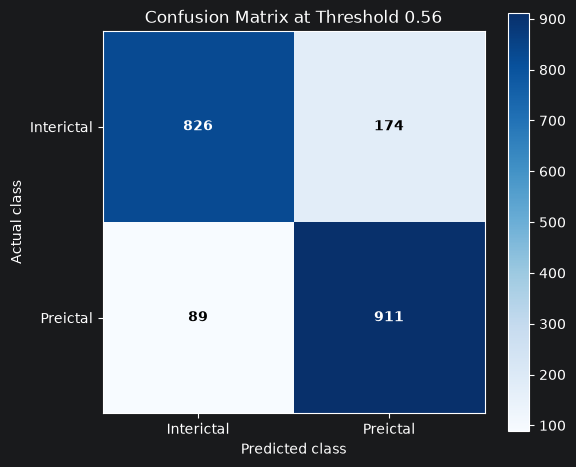

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\confusion_matrix_threshold_056.png


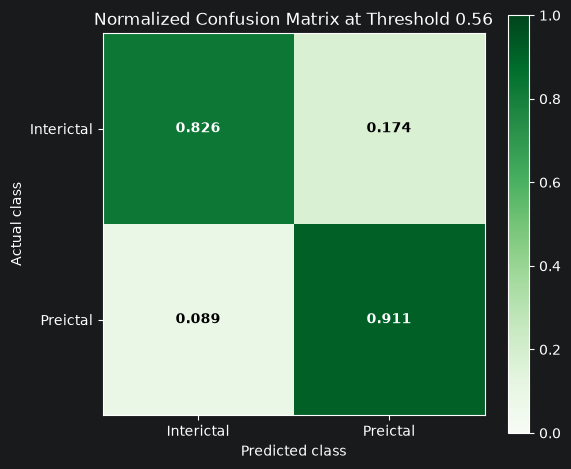

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\normalized_confusion_matrix_threshold_056.png


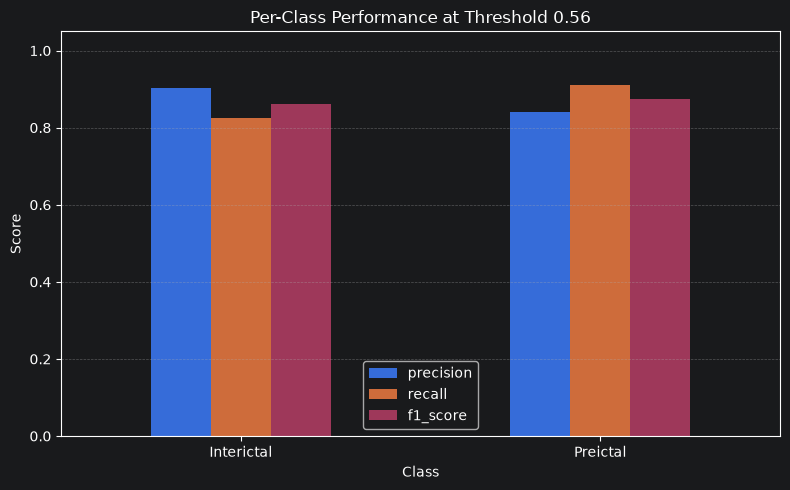

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\per_class_precision_recall_f1_threshold_056.png


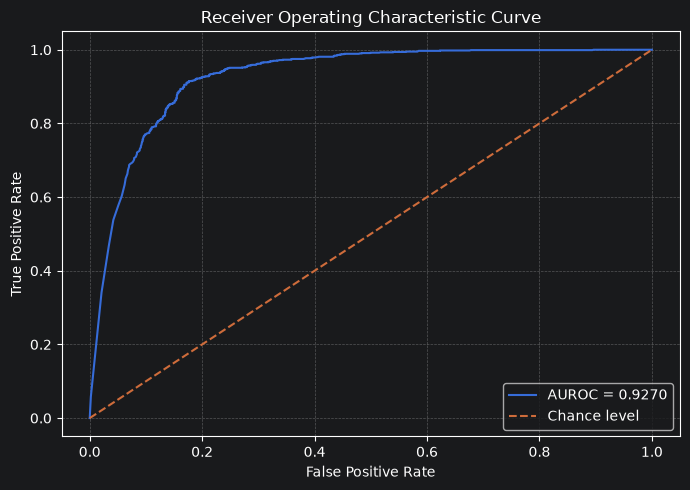

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\roc_curve_threshold_056.png


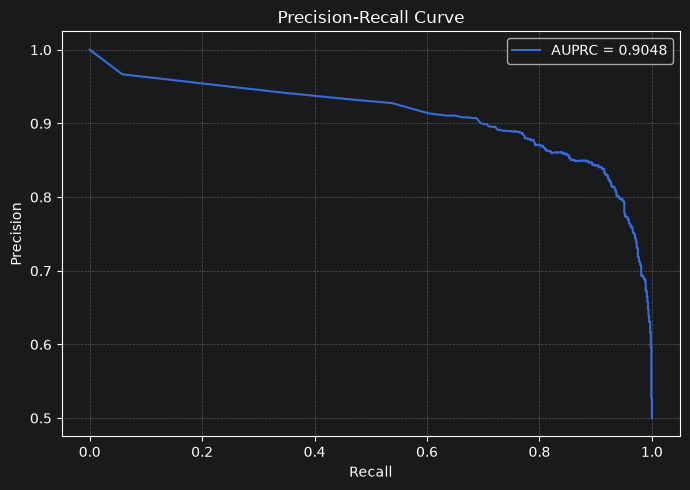

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\precision_recall_curve_threshold_056.png


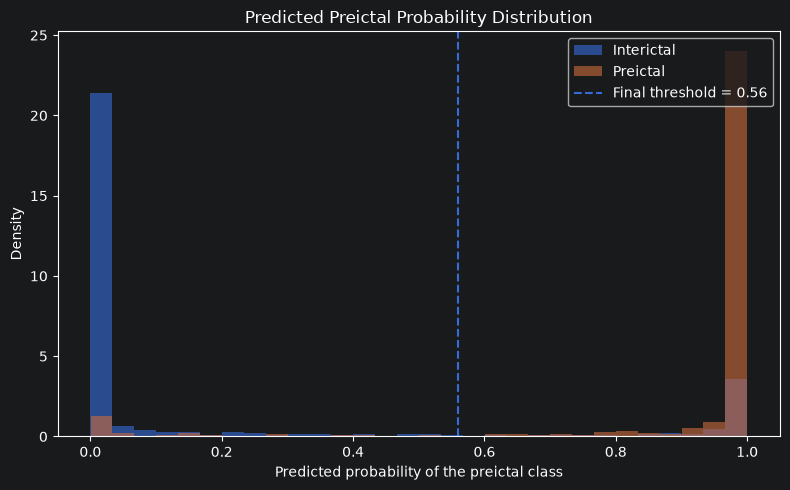

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\probability_distribution_threshold_056.png


In [32]:
from turtle import color
# =============================================================================
# REPORT-READY FIGURES AT THRESHOLD 0.56
# =============================================================================
from sklearn.metrics import roc_curve, precision_recall_curve

def save_figure(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


class_names = ["Interictal", "Preictal"]

# 1. Confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix at Threshold 0.56")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontweight="bold",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )
save_figure("confusion_matrix_threshold_056.png")

# 2. Normalized confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm_normalized, cmap="Greens", vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix at Threshold 0.56")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(
            j, i, f"{cm_normalized[i, j]:.3f}",
            ha="center", va="center",
            fontweight="bold",
            color="white" if cm_normalized[i, j] > 0.5 else "black"
        )
save_figure("normalized_confusion_matrix_threshold_056.png")
# 3. Per-class precision, recall, and F1
metric_plot_df = per_class_df.set_index("class")[
    ["precision", "recall", "f1_score"]
]
ax = metric_plot_df.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_title("Per-Class Performance at Threshold 0.56")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.4)
save_figure("per_class_precision_recall_f1_threshold_056.png")

# 4. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUROC = {overall_metrics['auroc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance level")
plt.title("Receiver Operating Characteristic Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
save_figure("roc_curve_threshold_056.png")

# 5. Precision-recall curve
pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(
    pr_recall,
    pr_precision,
    label=f"AUPRC = {overall_metrics['auprc']:.4f}",
)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
save_figure("precision_recall_curve_threshold_056.png")

# 6. Probability distributions
plt.figure(figsize=(8, 5))
plt.hist(
    y_prob[y_true == 0],
    bins=30,
    alpha=0.6,
    density=True,
    label="Interictal",
)
plt.hist(
    y_prob[y_true == 1],
    bins=30,
    alpha=0.6,
    density=True,
    label="Preictal",
)
plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label="Final threshold = 0.56",
)
plt.title("Predicted Preictal Probability Distribution")
plt.xlabel("Predicted probability of the preictal class")
plt.ylabel("Density")
plt.legend()
save_figure("probability_distribution_threshold_056.png")


# Threshold Tuning Analysis

Threshold tuning is needed because a lower threshold usually detects more preictal windows but also creates more false alarms. A higher threshold can reduce false alarms but may miss clinically important preictal windows.

The sweep below is included as a **sensitivity analysis only**. The final reported test metrics remain fixed at **0.56**, described as the validation-selected threshold for this 40-subject run.


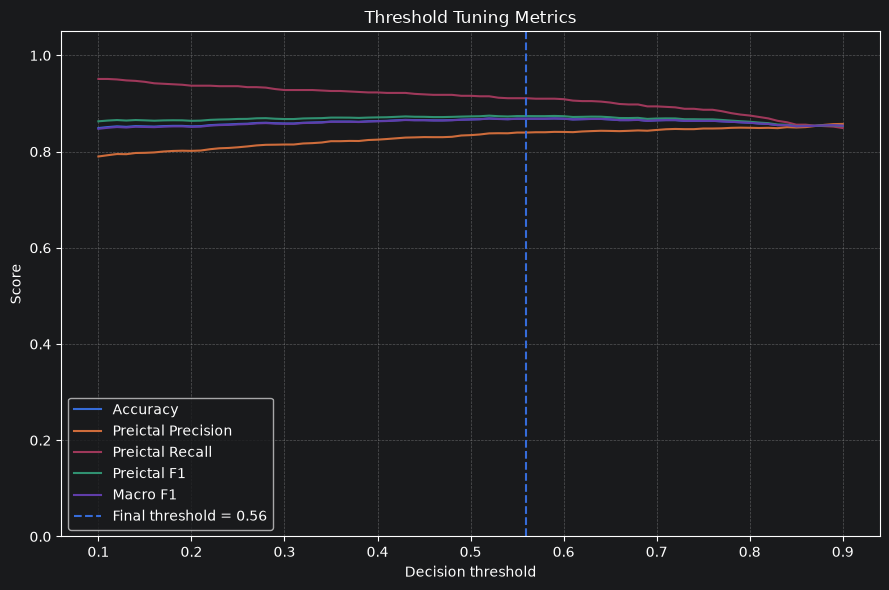

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\threshold_tuning_metrics_threshold_056.png


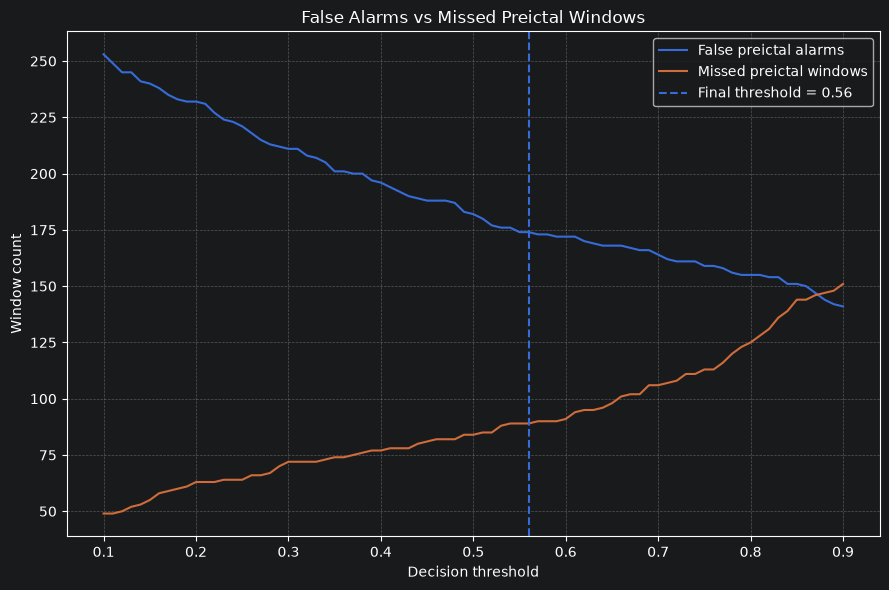

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\false_alarms_vs_missed_preictal_threshold_056.png
Threshold 0.56 row


,threshold,accuracy,preictal_precision,preictal_recall,preictal_f1,macro_f1,false_preictal_alarms,missed_preictal_windows,correct_preictal_windows,correct_interictal_windows
46,0.56,0.8685,0.839631,0.911,0.873861,0.868262,174,89,911,826


In [24]:
# =============================================================================
# THRESHOLD SWEEP FROM 0.10 TO 0.90
# =============================================================================
threshold_records = []

for threshold in np.round(np.arange(0.10, 0.901, 0.01), 2):
    threshold_pred = (y_prob >= threshold).astype(int)
    threshold_cm = confusion_matrix(
        y_true, threshold_pred, labels=[0, 1]
    )
    threshold_tn, threshold_fp, threshold_fn, threshold_tp = (
        threshold_cm.ravel()
    )

    threshold_records.append({
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, threshold_pred),
        "preictal_precision": precision_score(
            y_true, threshold_pred, pos_label=1, zero_division=0
        ),
        "preictal_recall": recall_score(
            y_true, threshold_pred, pos_label=1, zero_division=0
        ),
        "preictal_f1": f1_score(
            y_true, threshold_pred, pos_label=1, zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, threshold_pred, average="macro", zero_division=0
        ),
        "false_preictal_alarms": int(threshold_fp),
        "missed_preictal_windows": int(threshold_fn),
        "correct_preictal_windows": int(threshold_tp),
        "correct_interictal_windows": int(threshold_tn),
    })

threshold_df = pd.DataFrame(threshold_records)
threshold_df.to_csv(
    FINAL_EVAL_DIR / "threshold_tuning_table_threshold_056.csv",
    index=False,
)

# Threshold metrics graph
plt.figure(figsize=(9, 6))
for metric_name in [
    "accuracy",
    "preictal_precision",
    "preictal_recall",
    "preictal_f1",
    "macro_f1",
]:
    plt.plot(
        threshold_df["threshold"],
        threshold_df[metric_name],
        label=metric_name.replace("_", " ").title(),
    )
plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label="Final threshold = 0.56",
)
plt.title("Threshold Tuning Metrics")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
save_figure("threshold_tuning_metrics_threshold_056.png")

# False alarms versus missed preictal windows
plt.figure(figsize=(9, 6))
plt.plot(
    threshold_df["threshold"],
    threshold_df["false_preictal_alarms"],
    label="False preictal alarms",
)
plt.plot(
    threshold_df["threshold"],
    threshold_df["missed_preictal_windows"],
    label="Missed preictal windows",
)
plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label="Final threshold = 0.56",
)
plt.title("False Alarms vs Missed Preictal Windows")
plt.xlabel("Decision threshold")
plt.ylabel("Window count")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
save_figure("false_alarms_vs_missed_preictal_threshold_056.png")

print("Threshold 0.56 row")
display(
    threshold_df[
        np.isclose(threshold_df["threshold"], FINAL_THRESHOLD)
    ]
)


# Training-Curve Analysis

Training and validation curves help identify overfitting. Overfitting is suggested when training performance continues improving while validation loss worsens or validation F1/recall declines. The curves below are reconstructed from the saved training-history CSV; the model is not retrained.


Loaded training history: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\preictal_training_history_notebook.csv


,Epoch,GlobalStep,TrainLoss,TrainF1,TrainRecall,ValLoss,ValF1,ValRecall,ValPrecision,ValThreshold,ValF1_at_0_5,ValRecall_at_0_5,LR
25,26,4056,0.048181,0.984086,0.985368,0.632561,0.873226,0.923,0.828546,0.209595,0.867761,0.899,0.000057
26,27,4212,0.044927,0.987078,0.987573,0.667213,0.873639,0.923,0.829290,0.195923,0.870781,0.903,0.000045
27,28,4368,0.042453,0.987469,0.986776,0.679614,0.872745,0.919,0.830922,0.211792,0.870531,0.901,0.000035
28,29,4524,0.033804,0.989472,0.988579,0.688460,0.873814,0.921,0.831227,0.392822,0.871966,0.916,0.000026
29,30,4680,0.033546,0.988978,0.988978,0.708936,0.871615,0.869,0.874245,0.948242,0.869398,0.902,0.000019


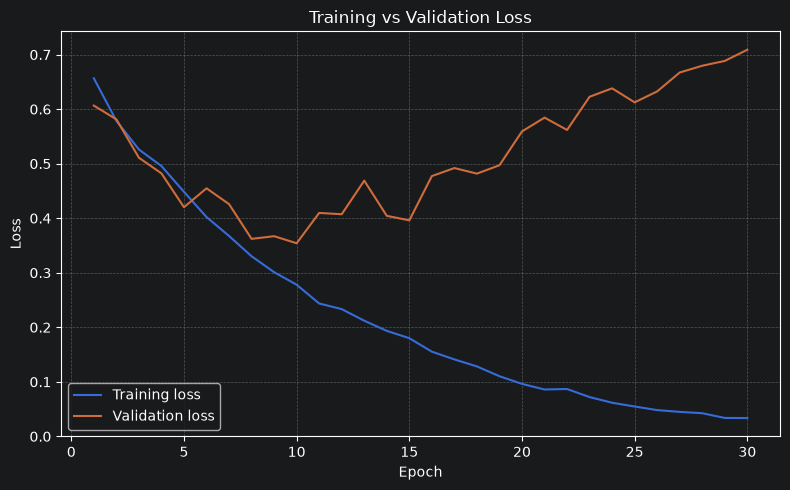

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\training_vs_validation_loss.png


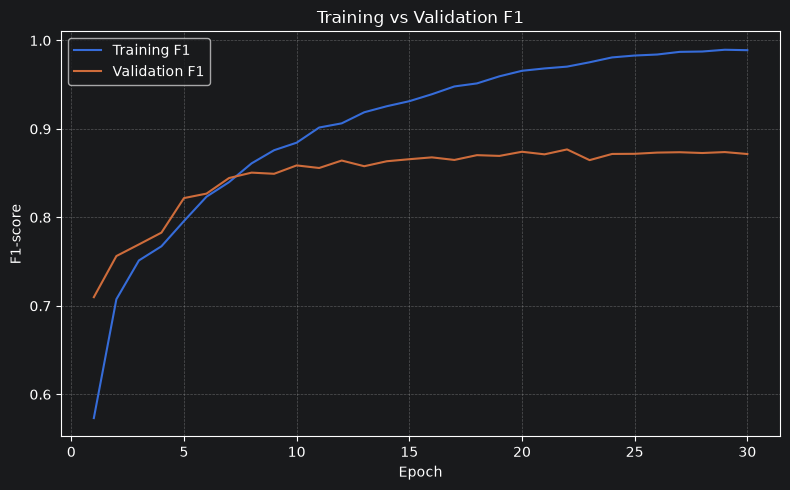

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\training_vs_validation_f1.png


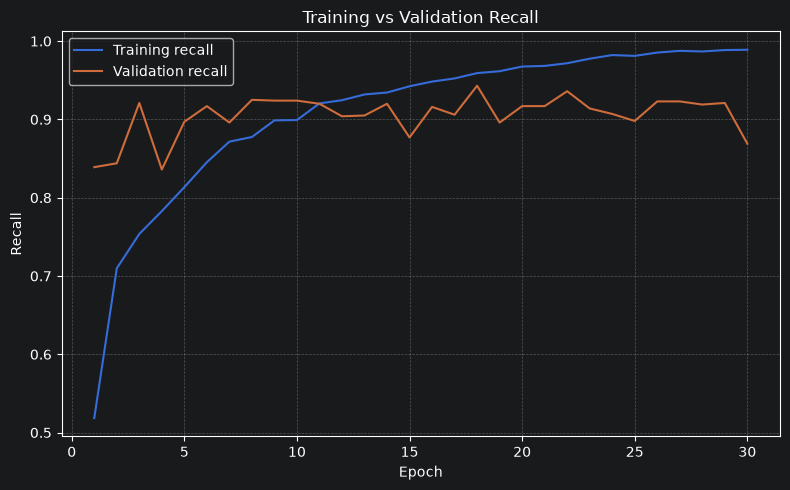

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\training_vs_validation_recall.png


In [25]:
# =============================================================================
# LOAD SAVED TRAINING HISTORY AND CREATE CURVES
# =============================================================================
history_candidates = [
    cfg.model_dir / "preictal_training_history_notebook.csv",
    cfg.model_dir / "preictal_training_history.csv",
    cfg.model_dir / "training_history.csv",
]
history_path = next((p for p in history_candidates if p.exists()), None)

if history_path is None:
    print("No saved training-history CSV was found. Training-curve figures were skipped.")
else:
    history_df = pd.read_csv(history_path)
    print("Loaded training history:", history_path)
    display(history_df.tail())

    epoch_col = "Epoch" if "Epoch" in history_df.columns else history_df.columns[0]

    # Training vs validation loss
    if {"TrainLoss", "ValLoss"}.issubset(history_df.columns):
        plt.figure(figsize=(8, 5))
        plt.plot(history_df[epoch_col], history_df["TrainLoss"], label="Training loss")
        plt.plot(history_df[epoch_col], history_df["ValLoss"], label="Validation loss")
        plt.title("Training vs Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(linestyle="--", alpha=0.4)
        save_figure("training_vs_validation_loss.png")

    # Training vs validation F1
    if {"TrainF1", "ValF1"}.issubset(history_df.columns):
        plt.figure(figsize=(8, 5))
        plt.plot(history_df[epoch_col], history_df["TrainF1"], label="Training F1")
        plt.plot(history_df[epoch_col], history_df["ValF1"], label="Validation F1")
        plt.title("Training vs Validation F1")
        plt.xlabel("Epoch")
        plt.ylabel("F1-score")
        plt.legend()
        plt.grid(linestyle="--", alpha=0.4)
        save_figure("training_vs_validation_f1.png")

    # Training vs validation recall
    if {"TrainRecall", "ValRecall"}.issubset(history_df.columns):
        plt.figure(figsize=(8, 5))
        plt.plot(
            history_df[epoch_col],
            history_df["TrainRecall"],
            label="Training recall",
        )
        plt.plot(
            history_df[epoch_col],
            history_df["ValRecall"],
            label="Validation recall",
        )
        plt.title("Training vs Validation Recall")
        plt.xlabel("Epoch")
        plt.ylabel("Recall")
        plt.legend()
        plt.grid(linestyle="--", alpha=0.4)
        save_figure("training_vs_validation_recall.png")


# EEG-Only vs Multimodal Saved-Checkpoint Comparison

This section loads the previously saved EEG-only checkpoint and evaluates it at the same fixed threshold, **0.56**. No retraining is performed.

The saved multimodal prediction table may be sorted by `RecordID` and `WindowStart`, while checkpoint inference follows the original `test_loader` order. Therefore, this section aligns EEG-only probabilities to the multimodal rows using stable sample identifiers such as `RecordID` + `WindowID` instead of requiring the two label arrays to have identical row order.

If exact identifier alignment is unavailable but the reconstructed test split has the same length and class totals, aggregate EEG-only metrics are still calculated in the loader's internally aligned order. The notebook clearly records which alignment method was used.


EEG-only checkpoint found:
D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG_EEG_ONLY_ABLATION\best_preictal_cnn_tcn_transformer.pt
Checkpoint loaded successfully.
Model architecture: d_model=96, heads=4, layers=2, dropout=0.25


EEG-only checkpoint inference: 100%|██████████| 32/32 [00:01<00:00, 16.75it/s]



EEG-only alignment:
Exact sample alignment completed with keys: RecordID + WindowID. The initial label-array difference was only a row-order difference.


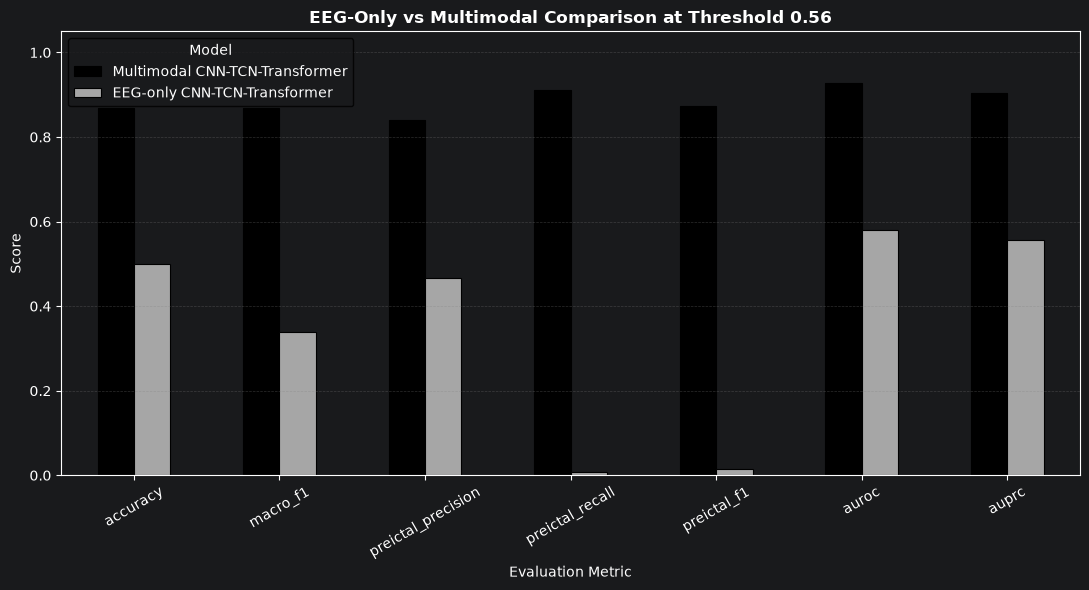

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\eeg_only_vs_multimodal_bar_chart_threshold_056.png


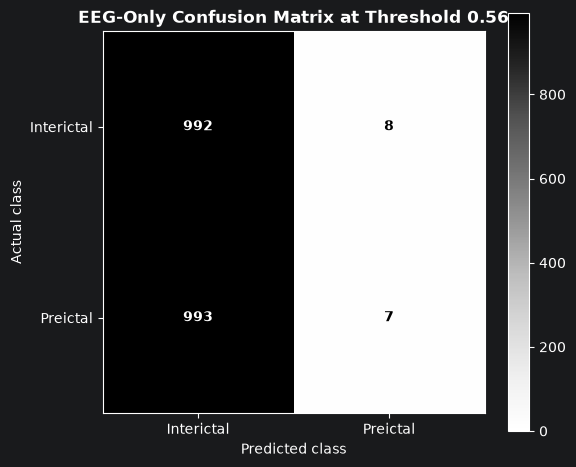

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\eeg_only_confusion_matrix_threshold_056.png


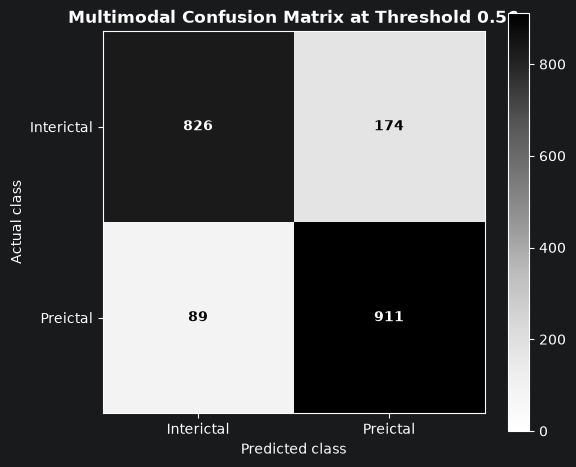

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\multimodal_confusion_matrix_for_ablation_threshold_056.png


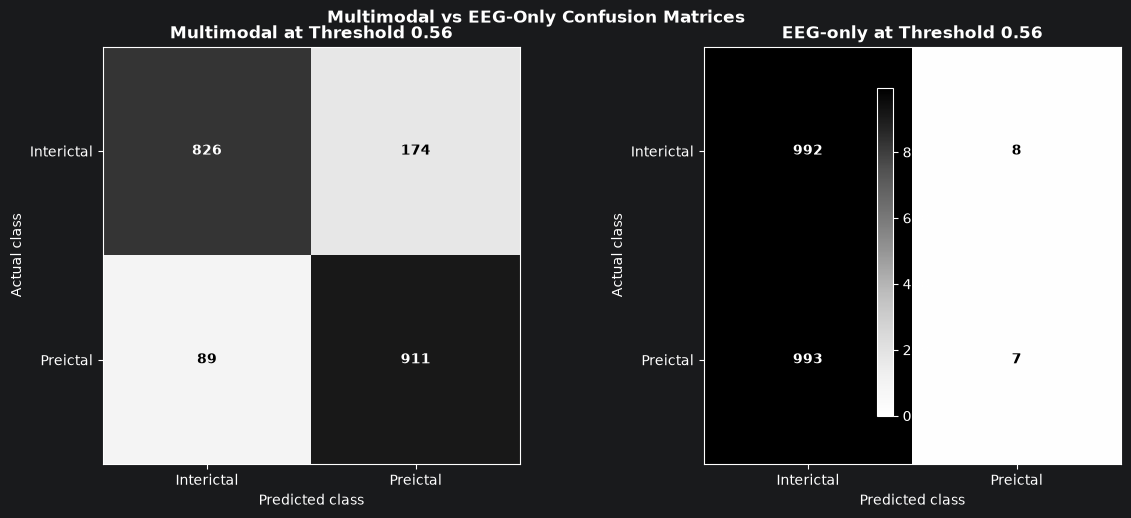

Saved: D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\clean_final_evaluation_threshold_056\figures\eeg_only_vs_multimodal_confusion_matrix_comparison_threshold_056.png

EEG-only vs multimodal comparison


,model,threshold,accuracy,macro_f1,preictal_precision,preictal_recall,preictal_f1,auroc,auprc,false_preictal_alarms,missed_preictal_windows,correct_preictal_windows,correct_interictal_windows,alignment_status
0,Multimodal CNN-TCN-Transformer,0.56,0.8685,0.868262,0.839631,0.911,0.873861,0.926990,0.904789,174,89,911,826,Saved multimodal prediction rows
1,EEG-only CNN-TCN-Transformer,0.56,0.4995,0.339225,0.466667,0.007,0.013793,0.580196,0.555310,8,993,7,992,Exact sample alignment completed with keys: Re...



Alignment status:
Exact sample alignment completed with keys: RecordID + WindowID. The initial label-array difference was only a row-order difference.

Interpretation:
The multimodal model achieved an equal or higher preictal F1-score than the EEG-only model in this window-level comparison. This supports the potential usefulness of complementary physiological and movement signals.


In [34]:
# =============================================================================
# EEG-ONLY SAVED-CHECKPOINT ABLATION WITH ROBUST TEST-WINDOW ALIGNMENT
# BLACK/GRAYSCALE REPORT FIGURES AT THRESHOLD 0.56
# =============================================================================

def predict_loader_eeg_masked(model, loader, device):
    """
    Run EEG-only inference by retaining EEG channels and masking all
    non-EEG modalities: ECG, EMG, accelerometer, and gyroscope.
    """
    model.eval()

    labels = []
    probabilities = []

    with torch.inference_mode():

        for x_batch, y_batch in tqdm(
            loader,
            desc="EEG-only checkpoint inference",
        ):
            x_batch = x_batch.to(
                device,
                non_blocking=True,
            )

            # Channels 0 and 1 contain EEG.
            # All remaining modalities are masked to zero.
            x_batch = x_batch.clone()
            x_batch[:, 2:, :] = 0.0

            with torch.cuda.amp.autocast(
                enabled=(device.type == "cuda")
            ):
                logits = model(x_batch)

            batch_probabilities = (
                torch.sigmoid(logits)
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            batch_labels = (
                y_batch.detach()
                .cpu()
                .numpy()
                .astype(int)
                .reshape(-1)
            )

            probabilities.extend(
                batch_probabilities.tolist()
            )

            labels.extend(
                batch_labels.tolist()
            )

    return (
        np.asarray(labels, dtype=int),
        np.asarray(probabilities, dtype=float),
    )


def comparison_metrics(
    model_name,
    labels,
    probabilities,
    threshold,
):
    """
    Calculate fixed-threshold comparison metrics for one model.
    """
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    local_cm = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    )

    local_tn, local_fp, local_fn, local_tp = (
        local_cm.ravel()
    )

    metrics = {
        "model": model_name,
        "threshold": threshold,

        "accuracy": accuracy_score(
            labels,
            predictions,
        ),

        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "preictal_precision": precision_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "preictal_recall": recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "preictal_f1": f1_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),

        "auroc": roc_auc_score(
            labels,
            probabilities,
        ),

        "auprc": average_precision_score(
            labels,
            probabilities,
        ),

        "false_preictal_alarms": int(local_fp),
        "missed_preictal_windows": int(local_fn),
        "correct_preictal_windows": int(local_tp),
        "correct_interictal_windows": int(local_tn),
    }

    return metrics, local_cm


def _canonical_sample_key(
    dataframe,
    columns,
):
    """
    Build a stable sample identifier without depending on exact
    floating-point timestamp formatting.
    """
    key_parts = []

    for column in columns:
        series = dataframe[column]

        if pd.api.types.is_numeric_dtype(series):

            # Round numeric timestamps to avoid differences caused by
            # CSV display precision.
            part = (
                pd.to_numeric(
                    series,
                    errors="coerce",
                )
                .round(6)
                .astype(str)
            )

        else:
            part = (
                series.astype(str)
                .str.strip()
            )

        key_parts.append(part)

    key = key_parts[0]

    for part in key_parts[1:]:
        key = key + "|" + part

    return key


def align_eeg_results_to_multimodal_rows(
    multimodal_df,
    reconstructed_test_df,
    loader_labels,
    loader_probabilities,
):
    """
    Align EEG-only inference results with the saved multimodal
    prediction row order.

    Returns
    -------
    aligned_labels
        EEG-only labels arranged in multimodal prediction order.

    aligned_probabilities
        EEG-only probabilities arranged in multimodal prediction order.

    aligned_dataframe
        Dataframe containing aligned EEG-only results.

    alignment_note
        Description of the alignment method used.
    """
    mm = (
        multimodal_df
        .reset_index(drop=True)
        .copy()
    )

    eeg = (
        reconstructed_test_df
        .reset_index(drop=True)
        .copy()
    )

    loader_labels = np.asarray(
        loader_labels,
        dtype=int,
    )

    loader_probabilities = np.asarray(
        loader_probabilities,
        dtype=float,
    )

    if len(eeg) != len(loader_labels):
        raise RuntimeError(
            "The reconstructed test dataframe and EEG inference "
            "have different lengths: "
            f"{len(eeg)} vs {len(loader_labels)}."
        )

    # test_loader must use shuffle=False. Therefore, its labels
    # should align directly with reconstructed test_df.
    reconstructed_labels = (
        eeg["Label"]
        .to_numpy(dtype=int)
    )

    if not np.array_equal(
        reconstructed_labels,
        loader_labels,
    ):
        mismatch_count = int(
            np.sum(
                reconstructed_labels
                != loader_labels
            )
        )

        raise RuntimeError(
            "EEG inference is not aligned with the reconstructed "
            "test loader. "
            f"Mismatched rows: {mismatch_count}. "
            "Recreate test_loader with shuffle=False before "
            "running this section."
        )

    eeg["EEG_Label"] = loader_labels

    eeg["EEG_Prob_Preictal"] = (
        loader_probabilities
    )

    # Try the most specific shared identifiers first.
    key_candidates = [
        ["RecordID", "WindowID"],
        ["RecordID", "WindowStart", "WindowEnd"],
        ["Subject", "Session", "Run", "WindowID"],
        ["ShardPath", "ShardIndex"],
    ]

    for key_columns in key_candidates:

        shared_columns_available = all(
            column in mm.columns
            and column in eeg.columns
            for column in key_columns
        )

        if not shared_columns_available:
            continue

        mm_key = _canonical_sample_key(
            mm,
            key_columns,
        )

        eeg_key = _canonical_sample_key(
            eeg,
            key_columns,
        )

        # Each key must identify exactly one test window.
        if (
            mm_key.duplicated().any()
            or eeg_key.duplicated().any()
        ):
            continue

        # Both evaluations must contain the same test-window set.
        if set(mm_key.tolist()) != set(eeg_key.tolist()):
            continue

        probability_map = pd.Series(
            eeg["EEG_Prob_Preictal"].to_numpy(
                dtype=float
            ),
            index=eeg_key,
        )

        label_map = pd.Series(
            eeg["EEG_Label"].to_numpy(
                dtype=int
            ),
            index=eeg_key,
        )

        aligned_probabilities = (
            mm_key
            .map(probability_map)
            .to_numpy(dtype=float)
        )

        aligned_labels = (
            mm_key
            .map(label_map)
            .to_numpy(dtype=int)
        )

        if np.isnan(
            aligned_probabilities
        ).any():
            continue

        multimodal_labels = (
            mm["Label"]
            .to_numpy(dtype=int)
        )

        if not np.array_equal(
            aligned_labels,
            multimodal_labels,
        ):
            mismatch_count = int(
                np.sum(
                    aligned_labels
                    != multimodal_labels
                )
            )

            raise RuntimeError(
                "Sample identifiers aligned, but the class "
                "labels differ for "
                f"{mismatch_count} windows. "
                "The checkpoints may not have been evaluated "
                "on the same test split."
            )

        aligned_df = mm.copy()

        aligned_df[
            "EEG_Prob_Preictal"
        ] = aligned_probabilities

        aligned_df[
            "EEG_PredictedLabel_Threshold_056"
        ] = (
            aligned_probabilities
            >= FINAL_THRESHOLD
        ).astype(int)

        alignment_note = (
            "Exact sample alignment completed with keys: "
            + " + ".join(key_columns)
            + ". The initial label-array difference was only "
              "a row-order difference."
        )

        return (
            aligned_labels,
            aligned_probabilities,
            aligned_df,
            alignment_note,
        )

    # -------------------------------------------------------------------------
    # Safe aggregate fallback
    # -------------------------------------------------------------------------
    # Metrics remain valid in loader order because every probability
    # remains paired with its corresponding EEG label.
    mm_labels = (
        mm["Label"]
        .to_numpy(dtype=int)
    )

    same_length = (
        len(mm_labels)
        == len(loader_labels)
    )

    same_class_totals = np.array_equal(
        np.bincount(
            mm_labels,
            minlength=2,
        ),
        np.bincount(
            loader_labels,
            minlength=2,
        ),
    )

    if same_length and same_class_totals:

        fallback_df = eeg.copy()

        fallback_df[
            "EEG_PredictedLabel_Threshold_056"
        ] = (
            loader_probabilities
            >= FINAL_THRESHOLD
        ).astype(int)

        alignment_note = (
            "No unique shared sample-key combination was available. "
            "EEG-only metrics were calculated in test_loader order. "
            "The row count and class totals match the multimodal "
            "evaluation, but exact row-level pairing could not be "
            "independently verified."
        )

        return (
            loader_labels,
            loader_probabilities,
            fallback_df,
            alignment_note,
        )

    raise RuntimeError(
        "The EEG-only and multimodal evaluations do not describe "
        "compatible test sets. Their lengths or class totals differ. "
        "Regenerate both prediction files from the same deterministic "
        "test dataframe."
    )


# =============================================================================
# MULTIMODAL FIXED-THRESHOLD RESULTS
# =============================================================================

multimodal_comparison_row, multimodal_cm = (
    comparison_metrics(
        "Multimodal CNN-TCN-Transformer",
        y_true,
        y_prob,
        FINAL_THRESHOLD,
    )
)

multimodal_comparison_row[
    "alignment_status"
] = "Saved multimodal prediction rows"


# =============================================================================
# LOCATE THE SAVED EEG-ONLY CHECKPOINT
# =============================================================================

eeg_model_dir = (
    cfg.model_dir.parent
    / f"{cfg.model_dir.name}_EEG_ONLY_ABLATION"
)

eeg_checkpoint_candidates = [
    eeg_model_dir
    / "best_preictal_cnn_tcn_transformer.pt",

    eeg_model_dir
    / "notebook_checkpoints"
    / "checkpoint_latest_epoch.pt",

    eeg_model_dir
    / "notebook_checkpoints"
    / "checkpoint_latest_step.pt",
]

EEG_CHECKPOINT_PATH = next(
    (
        path
        for path in eeg_checkpoint_candidates
        if path.exists()
    ),
    None,
)

eeg_comparison_available = (
    EEG_CHECKPOINT_PATH is not None
)

eeg_interpretation = (
    "No saved EEG-only checkpoint was found, so no EEG-only "
    "performance claim is made."
)

eeg_alignment_note = (
    "EEG-only checkpoint was not available."
)


# =============================================================================
# RUN SAVED-CHECKPOINT EEG-ONLY EVALUATION
# =============================================================================

if eeg_comparison_available:

    print("EEG-only checkpoint found:")
    print(EEG_CHECKPOINT_PATH)

    eeg_model, eeg_checkpoint, _ = (
        load_saved_model(
            EEG_CHECKPOINT_PATH,
            cfg,
            device,
        )
    )

    (
        eeg_loader_labels,
        eeg_loader_probabilities,
    ) = predict_loader_eeg_masked(
        eeg_model,
        test_loader,
        device,
    )

    (
        eeg_labels,
        eeg_probabilities,
        eeg_prediction_df,
        eeg_alignment_note,
    ) = align_eeg_results_to_multimodal_rows(
        pred_df,
        test_df,
        eeg_loader_labels,
        eeg_loader_probabilities,
    )

    print("\nEEG-only alignment:")
    print(eeg_alignment_note)

    # Save EEG-only predictions for reproducibility.
    eeg_prediction_df[
        "ReportingThreshold"
    ] = FINAL_THRESHOLD

    eeg_prediction_df.to_csv(
        FINAL_EVAL_DIR
        / "eeg_only_test_predictions_threshold_056.csv",
        index=False,
    )

    eeg_row, eeg_cm = comparison_metrics(
        "EEG-only CNN-TCN-Transformer",
        eeg_labels,
        eeg_probabilities,
        FINAL_THRESHOLD,
    )

    eeg_row[
        "alignment_status"
    ] = eeg_alignment_note

    comparison_df = pd.DataFrame([
        multimodal_comparison_row,
        eeg_row,
    ])


    # =========================================================================
    # INTERPRETATION
    # =========================================================================

    if (
        eeg_row["preictal_recall"] >= 0.80
        and eeg_row["false_preictal_alarms"]
        > multimodal_comparison_row[
            "false_preictal_alarms"
        ]
    ):
        eeg_interpretation = (
            "The EEG-only model has high preictal recall but also "
            "produces more false preictal alarms than the multimodal "
            "model. This indicates over-prediction of the preictal "
            "class. High recall alone does not establish that the "
            "EEG-only model is better."
        )

    elif (
        eeg_row["preictal_f1"]
        > multimodal_comparison_row[
            "preictal_f1"
        ]
    ):
        eeg_interpretation = (
            "The EEG-only model achieved a higher preictal F1-score "
            "in this window-level run. This finding requires "
            "confirmation through strict subject-wise and event-level "
            "evaluation."
        )

    else:
        eeg_interpretation = (
            "The multimodal model achieved an equal or higher "
            "preictal F1-score than the EEG-only model in this "
            "window-level comparison. This supports the potential "
            "usefulness of complementary physiological and movement "
            "signals."
        )


    # =========================================================================
    # BLACK-AND-GRAY COMPARISON BAR CHART
    # =========================================================================

    comparison_plot_metrics = [
        "accuracy",
        "macro_f1",
        "preictal_precision",
        "preictal_recall",
        "preictal_f1",
        "auroc",
        "auprc",
    ]

    comparison_plot_df = (
        comparison_df
        .set_index("model")[
            comparison_plot_metrics
        ]
        .T
    )

    ax = comparison_plot_df.plot(
        kind="bar",
        figsize=(11, 6),
        rot=30,

        # Multimodal = black; EEG-only = gray.
        color=["black", "0.65"],

        edgecolor="black",
        linewidth=0.8,
    )

    ax.set_title(
        "EEG-Only vs Multimodal Comparison at Threshold 0.56",
        fontweight="bold",
    )

    ax.set_xlabel(
        "Evaluation Metric"
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_ylim(
        0,
        1.05,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35,
        color="gray",
    )

    ax.legend(
        title="Model",
        frameon=True,
        edgecolor="black",
    )

    save_figure(
        "eeg_only_vs_multimodal_bar_chart_threshold_056.png"
    )


    # =========================================================================
    # EEG-ONLY BLACK/GRAYSCALE CONFUSION MATRIX
    # =========================================================================

    plt.figure(
        figsize=(6, 5)
    )

    plt.imshow(
        eeg_cm,
        cmap="Greys",
        vmin=0,
        vmax=eeg_cm.max(),
    )

    plt.title(
        "EEG-Only Confusion Matrix at Threshold 0.56",
        fontweight="bold",
    )

    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "Actual class"
    )

    plt.xticks(
        [0, 1],
        ["Interictal", "Preictal"],
    )

    plt.yticks(
        [0, 1],
        ["Interictal", "Preictal"],
    )

    plt.colorbar()

    for row_index in range(2):
        for column_index in range(2):

            value = eeg_cm[
                row_index,
                column_index,
            ]

            plt.text(
                column_index,
                row_index,
                f"{value}",
                ha="center",
                va="center",
                fontweight="bold",
                color=(
                    "white"
                    if value > eeg_cm.max() / 2
                    else "black"
                ),
            )

    save_figure(
        "eeg_only_confusion_matrix_threshold_056.png"
    )


    # =========================================================================
    # MULTIMODAL BLACK/GRAYSCALE CONFUSION MATRIX
    # =========================================================================

    plt.figure(
        figsize=(6, 5)
    )

    plt.imshow(
        multimodal_cm,
        cmap="Greys",
        vmin=0,
        vmax=multimodal_cm.max(),
    )

    plt.title(
        "Multimodal Confusion Matrix at Threshold 0.56",
        fontweight="bold",
    )

    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "Actual class"
    )

    plt.xticks(
        [0, 1],
        ["Interictal", "Preictal"],
    )

    plt.yticks(
        [0, 1],
        ["Interictal", "Preictal"],
    )

    plt.colorbar()

    for row_index in range(2):
        for column_index in range(2):

            value = multimodal_cm[
                row_index,
                column_index,
            ]

            plt.text(
                column_index,
                row_index,
                f"{value}",
                ha="center",
                va="center",
                fontweight="bold",
                color=(
                    "white"
                    if value
                    > multimodal_cm.max() / 2
                    else "black"
                ),
            )

    save_figure(
        "multimodal_confusion_matrix_for_ablation_threshold_056.png"
    )


    # =========================================================================
    # SIDE-BY-SIDE BLACK/GRAYSCALE CONFUSION MATRICES
    # =========================================================================

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
    )

    # Use the same color range so darkness is directly comparable.
    shared_maximum = max(
        multimodal_cm.max(),
        eeg_cm.max(),
    )

    matrices = [
        (
            axes[0],
            multimodal_cm,
            "Multimodal",
        ),
        (
            axes[1],
            eeg_cm,
            "EEG-only",
        ),
    ]

    for axis, matrix, title in matrices:

        image = axis.imshow(
            matrix,
            cmap="Greys",
            vmin=0,
            vmax=shared_maximum,
        )

        axis.set_title(
            f"{title} at Threshold 0.56",
            fontweight="bold",
        )

        axis.set_xlabel(
            "Predicted class"
        )

        axis.set_ylabel(
            "Actual class"
        )

        axis.set_xticks(
            [0, 1],
            ["Interictal", "Preictal"],
        )

        axis.set_yticks(
            [0, 1],
            ["Interictal", "Preictal"],
        )

        for row_index in range(2):
            for column_index in range(2):

                value = matrix[
                    row_index,
                    column_index,
                ]

                axis.text(
                    column_index,
                    row_index,
                    f"{value}",
                    ha="center",
                    va="center",
                    fontweight="bold",
                    color=(
                        "white"
                        if value > shared_maximum / 2
                        else "black"
                    ),
                )

    figure.colorbar(
        image,
        ax=axes.ravel().tolist(),
        shrink=0.85,
    )

    figure.suptitle(
        "Multimodal vs EEG-Only Confusion Matrices",
        fontweight="bold",
    )

    save_figure(
        "eeg_only_vs_multimodal_confusion_matrix_comparison_threshold_056.png"
    )


# =============================================================================
# EEG-ONLY CHECKPOINT NOT FOUND
# =============================================================================

else:
    comparison_df = pd.DataFrame([
        multimodal_comparison_row,
        {
            "model": "EEG-only CNN-TCN-Transformer",
            "threshold": FINAL_THRESHOLD,
            "status": (
                "Not evaluated: saved EEG-only "
                "checkpoint not found"
            ),
            "alignment_status": eeg_alignment_note,
        },
    ])

    print(eeg_interpretation)


# =============================================================================
# SAVE COMPARISON TABLE
# =============================================================================

comparison_df.to_csv(
    FINAL_EVAL_DIR
    / "eeg_only_vs_multimodal_comparison_threshold_056.csv",
    index=False,
)

print(
    "\nEEG-only vs multimodal comparison"
)

display(
    comparison_df
)

print(
    "\nAlignment status:"
)

print(
    eeg_alignment_note
)

print(
    "\nInterpretation:"
)

print(
    eeg_interpretation
)

# Final Report and Defence Summary

The generated report clearly identifies this as a preliminary balanced 40-subject, window-level experiment. It does not present the findings as clinical validation.


In [27]:
# =============================================================================
# WRITE FINAL REPORT SUMMARY
# =============================================================================
def pct(value):
    return f"{100.0 * float(value):.2f}%"


checkpoint_epoch = (
    loaded_checkpoint.get("epoch", "not recorded")
    if isinstance(loaded_checkpoint, dict)
    else "not recorded"
)
checkpoint_best_val_f1 = (
    loaded_checkpoint.get("best_val_f1", "not recorded")
    if isinstance(loaded_checkpoint, dict)
    else "not recorded"
)

summary_text = f"""# Final Report Summary — Threshold 0.56

## Experiment

- **Dataset:** SeizeIT2 wearable epilepsy dataset
- **Experiment:** Preliminary balanced 40-subject window-level experiment
- **Signals:** EEG, ECG, EMG, accelerometer, and gyroscope
- **Classes:** 0 = Interictal; 1 = Preictal
- **Preictal definition:** 35 minutes to 5 minutes before seizure onset
- **Window size:** 10 seconds
- **Model:** CNN-TCN-Transformer
- **Saved checkpoint:** `{CHECKPOINT_PATH}`
- **Checkpoint epoch:** {checkpoint_epoch}
- **Saved best validation F1:** {checkpoint_best_val_f1}
- **Final reporting threshold:** 0.56
- **Threshold statement:** 0.56 is treated as the validation-selected threshold for the 40-subject run.

## Fixed-Threshold Test Results

- **Accuracy:** {pct(overall_metrics['accuracy'])}
- **Balanced accuracy:** {pct(overall_metrics['balanced_accuracy'])}
- **Macro precision:** {pct(overall_metrics['macro_precision'])}
- **Macro recall:** {pct(overall_metrics['macro_recall'])}
- **Macro F1-score:** {pct(overall_metrics['macro_f1'])}
- **Weighted F1-score:** {pct(overall_metrics['weighted_f1'])}
- **Interictal precision:** {pct(overall_metrics['interictal_precision'])}
- **Interictal recall/specificity:** {pct(overall_metrics['interictal_recall_specificity'])}
- **Interictal F1-score:** {pct(overall_metrics['interictal_f1'])}
- **Preictal precision:** {pct(overall_metrics['preictal_precision'])}
- **Preictal recall:** {pct(overall_metrics['preictal_recall'])}
- **Preictal F1-score:** {pct(overall_metrics['preictal_f1'])}
- **Negative predictive value:** {pct(overall_metrics['negative_predictive_value'])}
- **Matthews correlation coefficient:** {overall_metrics['matthews_correlation_coefficient']:.4f}
- **AUROC:** {overall_metrics['auroc']:.4f}
- **AUPRC:** {overall_metrics['auprc']:.4f}
- **Brier score:** {overall_metrics['brier_score']:.4f}
- **False preictal alarms:** {overall_metrics['false_preictal_alarms']}
- **Missed preictal windows:** {overall_metrics['missed_preictal_windows']}

## EEG-Only Comparison

**Alignment status:** {eeg_alignment_note}

{eeg_interpretation}

## Interpretation

Recall is important because a missed preictal window may reduce the opportunity for an early warning. False alarms are also important because repeated unnecessary warnings can reduce usability and user trust. Therefore, preictal recall should be interpreted together with precision, F1-score, false alarms, and missed preictal windows.

The confusion matrix shows the counts of correct interictal predictions, false preictal alarms, missed preictal windows, and correct preictal predictions. AUROC measures ranking performance across thresholds, while AUPRC summarizes the precision-recall trade-off and is particularly informative for positive-event prediction.

Multimodal input may be useful because EEG, cardiac activity, muscular activity, and movement can provide complementary information. However, a fair conclusion requires an independently trained EEG-only model evaluated on exactly the same split.

## Limitations

- This is a preliminary balanced 40-subject window-level experiment.
- The balanced test distribution does not represent the natural prevalence of preictal periods.
- Window-level metrics do not directly measure seizure-event prediction performance.
- Subject-wise generalization and event-level false-alarm rates are still required.
- The threshold sweep is descriptive; final reporting remains fixed at 0.56.
- These results are promising experimental findings, not final clinical validation.

## Future Work

- Complete strict subject-wise cross-validation.
- Perform continuous-recording and seizure-event-level evaluation.
- Report false alarms per hour and seizure prediction horizon.
- Evaluate probability calibration on naturally imbalanced data.
- Compare independently trained EEG-only and multimodal models.
- Validate the framework on an external epilepsy dataset.

## Final Defence Statement

The experiment demonstrates the technical feasibility of multimodal preictal-window classification using a CNN-TCN-Transformer framework. The result should be described as promising but preliminary. Full subject-wise and event-level validation is required before any clinical-use claim can be made.
"""

summary_path = FINAL_EVAL_DIR / "final_report_summary_threshold_056.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nFinal summary saved to:")
print(summary_path)

print("\nAll fixed-threshold outputs:")
for output_path in sorted(FINAL_EVAL_DIR.rglob("*")):
    if output_path.is_file():
        print("-", output_path)


# Final Report Summary — Threshold 0.56

## Experiment

- **Dataset:** SeizeIT2 wearable epilepsy dataset
- **Experiment:** Preliminary balanced 40-subject window-level experiment
- **Signals:** EEG, ECG, EMG, accelerometer, and gyroscope
- **Classes:** 0 = Interictal; 1 = Preictal
- **Preictal definition:** 35 minutes to 5 minutes before seizure onset
- **Window size:** 10 seconds
- **Model:** CNN-TCN-Transformer
- **Saved checkpoint:** `D:\SeizeIT2_Preictal_Turbo_Outputs\models_preictal_cnn_tcn_transformer_balanced_near_sub125_40subjects_DEBUG\best_preictal_cnn_tcn_transformer.pt`
- **Checkpoint epoch:** 22
- **Saved best validation F1:** 0.8768149882899
- **Final reporting threshold:** 0.56
- **Threshold statement:** 0.56 is treated as the validation-selected threshold for the 40-subject run.

## Fixed-Threshold Test Results

- **Accuracy:** 86.85%
- **Balanced accuracy:** 86.85%
- **Macro precision:** 87.12%
- **Macro recall:** 86.85%
- **Macro F1-score:** 86.83%
- **Weighted F1-sc

# Final Defence Summary

- **Dataset used:** SeizeIT2 wearable epilepsy dataset  
- **Signals used:** EEG, ECG, EMG, accelerometer, and gyroscope  
- **Classes:** Interictal (`0`) and preictal (`1`)  
- **Preictal definition:** 35 to 5 minutes before seizure onset  
- **Window size:** 10 seconds  
- **Architecture:** CNN-TCN-Transformer  
- **Final threshold:** 0.56, treated as the validation-selected threshold for the 40-subject run  
- **Main results:** Generated automatically from the saved checkpoint in the preceding cells  
- **EEG-only comparison:** Generated only when a compatible saved EEG-only checkpoint is available  
- **Limitations:** Preliminary balanced 40-subject window-level experiment; not a clinical validation  
- **Future work:** Strict subject-wise testing, event-level evaluation, natural-imbalance testing, external validation, and false alarms per hour
